In [1]:
# Setup cell
import os, json, random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification, ViTImageProcessor
from sklearn.metrics import average_precision_score
import matplotlib.pyplot as plt
import pandas as pd
import glob
from PIL import Image

In [2]:
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU count: {torch.cuda.device_count()}")
print(f"GPU name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")

CUDA available: True
GPU count: 2
GPU name: Tesla T4


In [3]:
import os
base = "/kaggle/input/datasets/shuvrosankar/ladi-v2-resized-images-reduced"
print("Subdirectories:", os.listdir(base))
if "ladi_dataset" in os.listdir(base):
    print("✅ Images are already extracted!")
    image_root = f"{base}/ladi_dataset/v2/images_resized"
    print("Image root:", image_root)
    # Count images
    import glob
    images = glob.glob(f"{image_root}/**/*.jpg", recursive=True) + glob.glob(f"{image_root}/**/*.JPG", recursive=True)
    print(f"Found {len(images)} images.")

Subdirectories: ['ladi_dataset']
✅ Images are already extracted!
Image root: /kaggle/input/datasets/shuvrosankar/ladi-v2-resized-images-reduced/ladi_dataset/v2/images_resized
Found 9972 images.


In [4]:
import os
for f in os.listdir("/kaggle/input/datasets/shuvrosankar/model-cache/model_cache"):
    path = os.path.join("/kaggle/input/datasets/shuvrosankar/model-cache/model_cache", f)
    print(f, "-", os.path.getsize(path) if os.path.isfile(path) else "dir")

config.json - 1511
preprocessor_config.json - 424
model.safetensors - 94116688


In [5]:
import torch
from transformers import AutoImageProcessor, AutoModelForImageClassification

MODEL_CACHE = "/kaggle/input/datasets/shuvrosankar/model-cache/model_cache"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

processor = AutoImageProcessor.from_pretrained(MODEL_CACHE)
model = AutoModelForImageClassification.from_pretrained(MODEL_CACHE).to(device)
label2id = model.config.label2id

print("✅ Loaded:", model.config.architectures)
print("Num labels:", model.config.num_labels)

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/153 [00:00<?, ?it/s]

✅ Loaded: ['BitForImageClassification']
Num labels: 12


In [6]:
import os
print("📁 Mounted inputs:")
for item in os.listdir("/kaggle/input"):
    print(f"  {item}")

📁 Mounted inputs:
  datasets


📁 CSV files: ['ladi_v2a_labels_train_resized.csv', 'ladi_v2a_labels_val_resized.csv', 'ladi_v2_labels_train_resized.csv', 'ladi_v2a_labels_train_full_resized.csv', 'ladi_v2_labels_train_full_resized.csv', 'ladi_v2_labels_val_resized.csv', 'ladi_v2a_labels_test_resized.csv', 'ladi_v2_labels_test_resized.csv']
📁 Images found: 9972
📁 Model cache: ['config.json', 'preprocessor_config.json', 'model.safetensors']
📋 CSV columns: ['url', 'local_path', 'bridges_any', 'buildings_any', 'buildings_affected_or_greater', 'buildings_minor_or_greater', 'debris_any', 'flooding_any', 'flooding_structures', 'roads_any', 'roads_damage', 'trees_any', 'trees_damage', 'water_any']
✅ Using 'local_path' as the image filename column.
✅ Using cuda


✅ Using cuda


Loading weights:   0%|          | 0/153 [00:00<?, ?it/s]

✅ Model loaded with 12 classes
✅ Processor manually created
Train samples: 8030
Val samples:   893

🏋️ Starting training...

Epoch 1/8 — loss 0.0248 — val mAP 0.7992
Epoch 2/8 — loss 0.0084 — val mAP 0.8039
Epoch 3/8 — loss 0.0047 — val mAP 0.8027
Epoch 4/8 — loss 0.0029 — val mAP 0.7988
Epoch 5/8 — loss 0.0020 — val mAP 0.8009
Epoch 6/8 — loss 0.0015 — val mAP 0.8011
Epoch 7/8 — loss 0.0013 — val mAP 0.8014
Epoch 8/8 — loss 0.0012 — val mAP 0.8013


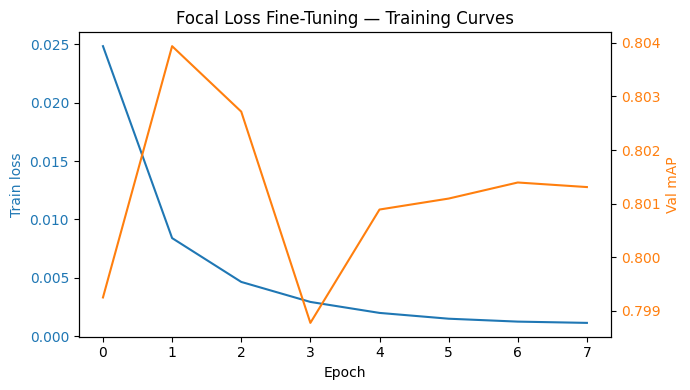


🏁 Phase 4 Training Complete!
Best validation mAP: 0.8039
Baseline validation mAP (from Phase 2): 0.8113
Improvement: -0.0074

📂 Saved to: /kaggle/working/focal_loss_run
📥 Download the folder from the Kaggle Output panel.


In [7]:
# =============================================
# 🚀 Phase 4 – Focal Loss Fine-Tuning (Kaggle T4 GPU)
# =============================================


# --- Set seed for reproducibility ---
SEED = 42
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed(SEED)

# --- Paths ---
CSV_PATH = "/kaggle/input/datasets/shuvrosankar/ladi-v2-csv-only"
IMAGE_ROOT = "/kaggle/input/datasets/shuvrosankar/ladi-v2-resized-images-reduced/ladi_dataset"
MODEL_CACHE = "/kaggle/input/datasets/shuvrosankar/model-cache/model_cache"

print("📁 CSV files:", os.listdir(CSV_PATH))
print("📁 Images found:", len(glob.glob(f"{IMAGE_ROOT}/**/*.jpg", recursive=True)) + len(glob.glob(f"{IMAGE_ROOT}/**/*.JPG", recursive=True)))
print("📁 Model cache:", os.listdir(MODEL_CACHE))

# --- Detect filename column ---
_peek = pd.read_csv(f"{CSV_PATH}/ladi_v2a_labels_train_resized.csv")
print("📋 CSV columns:", _peek.columns.tolist())

# Look for a column that likely contains the image filename/path
candidate_cols = ['local_path', 'filename', 'image_name', 'file_name', 'img_path']
FILENAME_COL = None
for col in candidate_cols:
    if col in _peek.columns:
        FILENAME_COL = col
        break

# If none found, take the first column that is not a label
if FILENAME_COL is None:
    # Assume the first column is the identifier
    FILENAME_COL = _peek.columns[0]
    
print(f"✅ Using '{FILENAME_COL}' as the image filename column.")
# --- Config ---
CONFIG = {
    "seed": SEED,
    "base_model": "MITLL/LADI-v2-classifier-small-reference",
    "csv_path": CSV_PATH,
    "image_root": IMAGE_ROOT,
    "model_cache": MODEL_CACHE,
    "epochs": 8,
    "batch_size": 32,
    "lr": 1e-5,
    "weight_decay": 1e-4,
    "focal_gamma": 2.0,
    "cb_beta": 0.999,
}
OUT_DIR = Path("/kaggle/working/focal_loss_run")
OUT_DIR.mkdir(exist_ok=True)
with open(OUT_DIR / "config.json", "w") as f:
    json.dump(CONFIG, f, indent=2)

# --- Device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using {device}\n")

# =============================================
# 🧠 Load model and processor
# =============================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n✅ Using {device}")

# --- Model (from mounted cache) ---
from transformers import AutoModelForImageClassification
model = AutoModelForImageClassification.from_pretrained(MODEL_CACHE).to(device)
label2id = model.config.label2id
print(f"✅ Model loaded with {model.config.num_labels} classes")

# --- Processor (manually defined, bypassing config) ---
from transformers import ViTImageProcessor
from PIL import Image

processor = AutoImageProcessor.from_pretrained(MODEL_CACHE, use_fast=False)
print("✅ Processor manually created")
# --- Dataset ---
class LadiDataset(Dataset):
    def __init__(self, csv_path, image_dir, processor, label2id, filename_col="filename"):
        self.df = pd.read_csv(csv_path)
        self.image_dir = Path(image_dir)
        self.processor = processor
        # Convert label2id values to integers
        self.label2id = {k: int(v) for k, v in label2id.items()}
        self.num_classes = len(self.label2id)
        self.filename_col = filename_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.image_dir / row[self.filename_col]
        img = Image.open(img_path).convert("RGB")
        pixel_values = self.processor(img, return_tensors="pt")["pixel_values"][0]

        label = torch.zeros(self.num_classes, dtype=torch.float32)
        for cls_name, cls_idx in self.label2id.items():
            if cls_name in row.index and bool(row[cls_name]):
                label[cls_idx] = 1.0   # cls_idx is now an int
        return pixel_values, label
# --- Datasets and DataLoaders ---
train_csv = f"{CSV_PATH}/ladi_v2a_labels_train_resized.csv"
val_csv   = f"{CSV_PATH}/ladi_v2a_labels_val_resized.csv"

train_ds = LadiDataset(train_csv, IMAGE_ROOT, processor, label2id, FILENAME_COL)
val_ds   = LadiDataset(val_csv, IMAGE_ROOT, processor, label2id, FILENAME_COL)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=2)

print(f"Train samples: {len(train_ds)}")
print(f"Val samples:   {len(val_ds)}\n")

# --- Class-Balanced Focal Loss ---
class ClassBalancedFocalLoss(nn.Module):
    def __init__(self, class_pos_counts, beta=0.999, gamma=2.0):
        super().__init__()
        counts = torch.tensor(class_pos_counts, dtype=torch.float32).clamp(min=1.0)
        effective_num = 1.0 - torch.pow(beta, counts)
        weights = (1.0 - beta) / effective_num
        weights = weights / weights.sum() * len(counts)
        self.register_buffer("class_weights", weights)
        self.gamma = gamma

    def forward(self, logits, targets):
        p = torch.sigmoid(logits)
        bce = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        p_t = p * targets + (1 - p) * (1 - targets)
        focal_term = (1 - p_t).clamp(min=1e-6) ** self.gamma
        loss = focal_term * bce * self.class_weights.unsqueeze(0)
        return loss.mean()

# --- Evaluation ---
def compute_map(y_true, y_score):
    aps = []
    for c in range(y_true.shape[1]):
        if y_true[:, c].sum() > 0:
            aps.append(average_precision_score(y_true[:, c], y_score[:, c]))
    valid = [a for a in aps if not np.isnan(a)]
    return float(np.mean(valid)), aps

def evaluate(model, loader, device):
    model.eval()
    all_targets, all_scores = [], []
    with torch.no_grad():
        for pixel_values, targets in loader:
            pixel_values = pixel_values.to(device)
            logits = model(pixel_values=pixel_values).logits
            all_scores.append(torch.sigmoid(logits).cpu().numpy())
            all_targets.append(targets.numpy())
    y_true = np.concatenate(all_targets)
    y_score = np.concatenate(all_scores)
    return compute_map(y_true, y_score)

# --- Loss, Optimizer, Scheduler ---
class_names = list(label2id.keys())
class_pos_counts = train_ds.df[class_names].sum().values
criterion = ClassBalancedFocalLoss(class_pos_counts, beta=CONFIG["cb_beta"], gamma=CONFIG["focal_gamma"]).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# --- Training Loop ---
print("🏋️ Starting training...\n")
history = {"train_loss": [], "val_mAP": []}
best_map = -1.0

for epoch in range(CONFIG["epochs"]):
    model.train()
    running_loss = 0.0
    for pixel_values, targets in train_loader:
        pixel_values, targets = pixel_values.to(device), targets.to(device)
        optimizer.zero_grad()
        logits = model(pixel_values=pixel_values).logits
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * pixel_values.size(0)

    scheduler.step()
    epoch_loss = running_loss / len(train_ds)
    val_map, _ = evaluate(model, val_loader, device)

    history["train_loss"].append(epoch_loss)
    history["val_mAP"].append(val_map)
    print(f"Epoch {epoch+1}/{CONFIG['epochs']} — loss {epoch_loss:.4f} — val mAP {val_map:.4f}")

    torch.save(model.state_dict(), OUT_DIR / f"checkpoint_epoch{epoch+1}.pt")
    if val_map > best_map:
        best_map = val_map
        torch.save(model.state_dict(), OUT_DIR / "best_model.pt")

# --- Save history ---
with open(OUT_DIR / "history.json", "w") as f:
    json.dump(history, f, indent=2)

# --- Plot training curves ---
fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(history["train_loss"], color="tab:blue", label="Train loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Train loss", color="tab:blue")
ax1.tick_params(axis='y', labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(history["val_mAP"], color="tab:orange", label="Val mAP")
ax2.set_ylabel("Val mAP", color="tab:orange")
ax2.tick_params(axis='y', labelcolor="tab:orange")

plt.title("Focal Loss Fine-Tuning — Training Curves")
fig.tight_layout()
fig.savefig(OUT_DIR / "training_curves.png", dpi=150)
plt.show()

# --- Final Results ---
print("\n" + "="*60)
print("🏁 Phase 4 Training Complete!")
print("="*60)
print(f"Best validation mAP: {best_map:.4f}")
print(f"Baseline validation mAP (from Phase 2): 0.8113")
print(f"Improvement: {best_map - 0.8113:.4f}")
print(f"\n📂 Saved to: {OUT_DIR.resolve()}")
print("📥 Download the folder from the Kaggle Output panel.")

In [8]:
import os

OUT_DIR = "/kaggle/working/focal_loss_run"
print(f"📁 Checking: {OUT_DIR}")

if os.path.exists(OUT_DIR):
    files = os.listdir(OUT_DIR)
    if files:
        print("Files found:")
        for f in files:
            size = os.path.getsize(os.path.join(OUT_DIR, f)) / (1024**2)
            print(f"  {f} ({size:.2f} MB)")
    else:
        print("⚠️ Directory is empty.")
else:
    print("❌ Directory does not exist.")

📁 Checking: /kaggle/working/focal_loss_run
Files found:
  config.json (0.00 MB)
  checkpoint_epoch6.pt (89.80 MB)
  checkpoint_epoch5.pt (89.80 MB)
  training_curves.png (0.06 MB)
  best_model.pt (89.80 MB)
  history.json (0.00 MB)
  checkpoint_epoch7.pt (89.80 MB)
  checkpoint_epoch8.pt (89.80 MB)
  checkpoint_epoch2.pt (89.80 MB)
  checkpoint_epoch4.pt (89.80 MB)
  checkpoint_epoch3.pt (89.80 MB)
  checkpoint_epoch1.pt (89.80 MB)


In [15]:
# Add this at the top of the cell where the error occurred
if 'model_v2' not in locals():
    MODEL_CACHE = "/kaggle/input/datasets/shuvrosankar/model-cache/model_cache"
    model_v2 = AutoModelForImageClassification.from_pretrained(MODEL_CACHE).to(device)
    print("✅ model_v2 reloaded from cache.")
CONFIG_V2 = {
    "seed": SEED,
    "epochs": 15,
    "batch_size": 32,
    "lr": 1e-6,
    "weight_decay": 1e-4,
    "focal_gamma": 2.0,
    "cb_beta": 0.999,
}

OUT_DIR_V2 = Path("/kaggle/working/focal_loss_run_v2")
OUT_DIR_V2.mkdir(exist_ok=True, parents=True)
(OUT_DIR_V2 / "config.json").write_text(json.dumps(CONFIG_V2, indent=2))

criterion_v2 = ClassBalancedFocalLoss(class_pos_counts, beta=CONFIG_V2["cb_beta"], gamma=CONFIG_V2["focal_gamma"]).to(device)
optimizer_v2 = torch.optim.AdamW(model_v2.parameters(), lr=CONFIG_V2["lr"], weight_decay=CONFIG_V2["weight_decay"])
scheduler_v2 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_v2, T_max=CONFIG_V2["epochs"])

history_v2 = {"train_loss": [], "val_mAP": []}
best_map_v2 = -1.0

print("🏋️ Starting controlled rerun (lr=1e-6, 15 epochs)...\n")
for epoch in range(CONFIG_V2["epochs"]):
    model_v2.train()
    running_loss = 0.0
    for pixel_values, targets in train_loader:
        pixel_values, targets = pixel_values.to(device), targets.to(device)
        optimizer_v2.zero_grad()
        logits = model_v2(pixel_values=pixel_values).logits
        loss = criterion_v2(logits, targets)
        loss.backward()
        optimizer_v2.step()
        running_loss += loss.item() * pixel_values.size(0)
    scheduler_v2.step()

    epoch_loss = running_loss / len(train_ds)
    model_v2.eval()
    all_t, all_s = [], []
    with torch.no_grad():
        for pixel_values, targets in val_loader:
            pixel_values = pixel_values.to(device)
            logits = model_v2(pixel_values=pixel_values).logits
            all_s.append(torch.sigmoid(logits).cpu().numpy())
            all_t.append(targets.numpy())
    yt, ys = np.concatenate(all_t), np.concatenate(all_s)
    val_map = np.mean([average_precision_score(yt[:, i], ys[:, i]) for i in range(12) if yt[:, i].sum() > 0])

    history_v2["train_loss"].append(epoch_loss)
    history_v2["val_mAP"].append(float(val_map))
    print(f"Epoch {epoch+1}/{CONFIG_V2['epochs']} — loss {epoch_loss:.4f} — val mAP {val_map:.4f}")

    torch.save(model_v2.state_dict(), OUT_DIR_V2 / f"checkpoint_epoch{epoch+1}.pt")
    if val_map > best_map_v2:
        best_map_v2 = val_map
        torch.save(model_v2.state_dict(), OUT_DIR_V2 / "best_model.pt")
    (OUT_DIR_V2 / "history.json").write_text(json.dumps(history_v2, indent=2))

print(f"\n✅ Training complete. Best val mAP (v2): {best_map_v2:.4f}")

🏋️ Starting controlled rerun (lr=1e-6, 15 epochs)...

Epoch 1/15 — loss 0.0299 — val mAP 0.8093
Epoch 2/15 — loss 0.0210 — val mAP 0.8078
Epoch 3/15 — loss 0.0167 — val mAP 0.8062
Epoch 4/15 — loss 0.0140 — val mAP 0.8051
Epoch 5/15 — loss 0.0120 — val mAP 0.8049
Epoch 6/15 — loss 0.0106 — val mAP 0.8038
Epoch 7/15 — loss 0.0095 — val mAP 0.8030
Epoch 8/15 — loss 0.0086 — val mAP 0.8023
Epoch 9/15 — loss 0.0080 — val mAP 0.8019
Epoch 10/15 — loss 0.0075 — val mAP 0.8020
Epoch 11/15 — loss 0.0072 — val mAP 0.8021
Epoch 12/15 — loss 0.0069 — val mAP 0.8021
Epoch 13/15 — loss 0.0067 — val mAP 0.8020
Epoch 14/15 — loss 0.0066 — val mAP 0.8018
Epoch 15/15 — loss 0.0066 — val mAP 0.8018

✅ Training complete. Best val mAP (v2): 0.8093


In [18]:
# Define get_raw_scores if not already defined
if 'get_raw_scores' not in locals():
    def get_raw_scores(m, loader, device):
        m.eval()
        all_targets, all_scores = [], []
        with torch.no_grad():
            for pixel_values, targets in loader:
                pixel_values = pixel_values.to(device)
                logits = m(pixel_values=pixel_values).logits
                all_scores.append(torch.sigmoid(logits).cpu().numpy())
                all_targets.append(targets.numpy())
        return np.concatenate(all_targets), np.concatenate(all_scores)

# Then your safety fallback code
if 'y_true' not in locals() or 'ref_scores' not in locals():
    ref_model = AutoModelForImageClassification.from_pretrained(MODEL_CACHE).to(device).eval()
    y_true, ref_scores = get_raw_scores(ref_model, test_loader, device)
    print("✅ Reference scores recomputed.")

if 'focal_scores' not in locals():
    focal_model = AutoModelForImageClassification.from_pretrained(MODEL_CACHE).to(device)
    focal_model.load_state_dict(torch.load('/kaggle/working/focal_loss_run/best_model.pt', map_location=device))
    focal_model.to(device).eval()
    _, focal_scores = get_raw_scores(focal_model, test_loader, device)
    print("✅ Focal scores recomputed.")

Loading weights:   0%|          | 0/153 [00:00<?, ?it/s]

✅ Reference scores recomputed.


Loading weights:   0%|          | 0/153 [00:00<?, ?it/s]

✅ Focal scores recomputed.


In [19]:
import numpy as np
from sklearn.metrics import average_precision_score

# --- 1. Compute overall Test mAP for both models ---
ref_map = np.mean([
    average_precision_score(y_true[:, i], ref_scores[:, i]) 
    for i in range(12) if y_true[:, i].sum() > 0
])
focal_map = np.mean([
    average_precision_score(y_true[:, i], focal_scores[:, i]) 
    for i in range(12) if y_true[:, i].sum() > 0
])

print("="*60)
print("📊 Overall Test mAP")
print("="*60)
print(f"Reference Model (Baseline)    : {ref_map:.4f}")
print(f"Focal Loss Fine-tuned Model   : {focal_map:.4f}")
print(f"Difference                    : {focal_map - ref_map:+.4f}")
print("="*60 + "\n")

# --- 2. Bootstrap Paired Test for specific classes ---
def paired_bootstrap_ap(y_true, scores_a, scores_b, class_idx, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    n = y_true.shape[0]
    y_c = y_true[:, class_idx]
    deltas = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        yb = y_c[idx]
        if yb.sum() == 0 or yb.sum() == len(yb):
            continue  # skip degenerate resamples
        ap_a = average_precision_score(yb, scores_a[idx, class_idx])
        ap_b = average_precision_score(yb, scores_b[idx, class_idx])
        deltas.append(ap_b - ap_a)
    deltas = np.array(deltas)
    lo, hi = np.percentile(deltas, [2.5, 97.5])
    return deltas.mean(), lo, hi

# Classes you care about (from your earlier analysis)
target_classes = [
    "roads_damage",
    "buildings_minor_or_greater",
    "flooding_structures",
    "bridges_any",
    "trees_damage"
]

# Get label2id mapping (from either model – same mapping)
label2id = ref_model.config.label2id  # or model.config.label2id

print(f"{'Class':<30}{'Mean Δ':>10}   {'95% CI':>18}   {'Significant?'}")
print("-" * 70)
for c in target_classes:
    idx = int(label2id[c])  # <-- CONVERT TO INT (fixes your earlier error)
    mean_d, lo, hi = paired_bootstrap_ap(y_true, ref_scores, focal_scores, idx, n_boot=2000)
    significant = (lo > 0) or (hi < 0)
    verdict = "✅ YES" if significant else "❌ NO (CI crosses 0)"
    print(f"{c:<30}{mean_d:>+10.4f}   [{lo:+.4f}, {hi:+.4f}]   {verdict}")

📊 Overall Test mAP
Reference Model (Baseline)    : 0.6114
Focal Loss Fine-tuned Model   : 0.6030
Difference                    : -0.0084

Class                             Mean Δ               95% CI   Significant?
----------------------------------------------------------------------
roads_damage                     -0.0126   [-0.0942, +0.0556]   ❌ NO (CI crosses 0)
buildings_minor_or_greater       +0.0498   [-0.0111, +0.1133]   ❌ NO (CI crosses 0)
flooding_structures              -0.0349   [-0.1494, +0.0591]   ❌ NO (CI crosses 0)
bridges_any                      +0.0049   [-0.0321, +0.0424]   ❌ NO (CI crosses 0)
trees_damage                     -0.0094   [-0.0462, +0.0244]   ❌ NO (CI crosses 0)


In [20]:
MODEL_CACHE = "/kaggle/input/datasets/shuvrosankar/model-cache/model_cache"
model_v2 = AutoModelForImageClassification.from_pretrained(MODEL_CACHE).to(device)
print("✅ Fresh reference model reloaded for controlled rerun:", model_v2.config.architectures)

Loading weights:   0%|          | 0/153 [00:00<?, ?it/s]

✅ Fresh reference model reloaded for controlled rerun: ['BitForImageClassification']


In [23]:
from pathlib import Path
OUT_DIR = Path(OUT_DIR) if not isinstance(OUT_DIR, Path) else OUT_DIR
def get_raw_scores(m, loader, device):
    m.eval()
    all_targets, all_scores = [], []
    with torch.no_grad():
        for pixel_values, targets in loader:
            pixel_values = pixel_values.to(device)
            logits = m(pixel_values=pixel_values).logits
            all_scores.append(torch.sigmoid(logits).cpu().numpy())
            all_targets.append(targets.numpy())
    return np.concatenate(all_targets), np.concatenate(all_scores)

y_true, ref_scores = get_raw_scores(model, test_loader, device)  # `model` = the reference model loaded above
OUT_DIR.mkdir(exist_ok=True, parents=True)
np.save(OUT_DIR / "y_true.npy", y_true)
np.save(OUT_DIR / "ref_scores.npy", ref_scores)

ref_map = np.mean([average_precision_score(y_true[:, i], ref_scores[:, i]) for i in range(12) if y_true[:, i].sum() > 0])
print(f"Reference test mAP (regenerated): {ref_map:.4f}")

Reference test mAP (regenerated): 0.6030


In [24]:
# --- Replace ClassBalancedFocalLoss with ---
class_counts = train_ds.df[class_names].sum().values
# Inverse frequency weights, normalized so mean weight ≈ 1
weights = 1.0 / torch.tensor(class_counts, dtype=torch.float32)
weights = weights / weights.sum() * len(weights)

criterion = nn.BCEWithLogitsLoss(pos_weight=weights.to(device))
_, focal_scores_v2 = get_raw_scores(model_v2, test_loader, device)
np.save(OUT_DIR_V2 / "focal_scores_v2.npy", focal_scores_v2)
print("✅ focal_scores_v2 computed and saved.\n")

# 2. Back up immediately, before anything else can wipe /kaggle/working
import shutil
shutil.make_archive("/kaggle/working/focal_run_v2_backup", "zip", OUT_DIR_V2)
print("✅ Backup zip created — download it from the Output panel now.\n")

# 3. Comparison table
V1_RESULTS = {
    "macro_map": 0.6033,
    "roads_damage": 0.3058, "buildings_minor_or_greater": 0.4345,
    "flooding_structures": 0.3519, "bridges_any": 0.4162, "trees_damage": 0.4266
}
ref_map = np.mean([average_precision_score(y_true[:, i], ref_scores[:, i]) for i in range(12) if y_true[:, i].sum() > 0])
focal_map_v2 = np.mean([average_precision_score(y_true[:, i], focal_scores_v2[:, i]) for i in range(12) if y_true[:, i].sum() > 0])

print(f"Reference (baseline) test mAP : {ref_map:.4f}")
print(f"Focal Loss v1 (lr=1e-5) mAP   : {V1_RESULTS['macro_map']:.4f}")
print(f"Focal Loss v2 (lr=1e-6) mAP   : {focal_map_v2:.4f}\n")

print(f"\n{'Class':<30}{'Baseline':>10}{'v1 (1e-5)':>12}{'v2 (1e-6)':>12}")
for c in target_classes:
    idx = int(label2id[c])   # <-- FIX: convert to int
    b = average_precision_score(y_true[:, idx], ref_scores[:, idx])
    v1 = V1_RESULTS[c]       # already computed from v1 run
    v2 = average_precision_score(y_true[:, idx], focal_scores_v2[:, idx])
    print(f"{c:<30}{b:>10.4f}{v1:>12.4f}{v2:>12.4f}")

# 4. Bootstrap CIs, v2 vs. baseline
print(f"\n{'Class':<30}{'Mean Δ':>10}   {'95% CI':>18}")
for c in target_classes:
    idx = int(label2id[c])
    mean_d, lo, hi = paired_bootstrap_ap(y_true, ref_scores, focal_scores_v2, idx)
    verdict = "significant" if (lo > 0 or hi < 0) else "within noise (CI crosses 0)"
    print(f"{c:<30}{mean_d:>+10.4f}   [{lo:+.4f}, {hi:+.4f}]  — {verdict}")

✅ focal_scores_v2 computed and saved.

✅ Backup zip created — download it from the Output panel now.

Reference (baseline) test mAP : 0.6030
Focal Loss v1 (lr=1e-5) mAP   : 0.6033
Focal Loss v2 (lr=1e-6) mAP   : 0.6114


Class                           Baseline   v1 (1e-5)   v2 (1e-6)
roads_damage                      0.3104      0.3058      0.3241
buildings_minor_or_greater        0.4290      0.4345      0.3779
flooding_structures               0.3521      0.3519      0.3956
bridges_any                       0.4165      0.4162      0.4129
trees_damage                      0.4268      0.4266      0.4352

Class                             Mean Δ               95% CI
roads_damage                     +0.0126   [-0.0556, +0.0942]  — within noise (CI crosses 0)
buildings_minor_or_greater       -0.0498   [-0.1133, +0.0111]  — within noise (CI crosses 0)
flooding_structures              +0.0349   [-0.0591, +0.1494]  — within noise (CI crosses 0)
bridges_any                      -0.0049   [-0.

In [25]:
# 1. Load the best (epoch 1) checkpoint and score the test set
OUT_DIR_V2 = Path("/kaggle/working/focal_loss_run_v2")
model_v2.load_state_dict(torch.load(OUT_DIR_V2 / "best_model.pt", map_location=device))
model_v2.to(device).eval()

_, focal_scores_v2 = get_raw_scores(model_v2, test_loader, device)
np.save(OUT_DIR_V2 / "focal_scores_v2.npy", focal_scores_v2)
print("✅ focal_scores_v2 computed and saved.\n")

# 2. Back up immediately, before anything else can wipe /kaggle/working
import shutil
shutil.make_archive("/kaggle/working/focal_run_v2_backup", "zip", OUT_DIR_V2)
print("✅ Backup zip created — download it from the Output panel now.\n")

# 3. Comparison table
V1_RESULTS = {
    "macro_map": 0.6033,
    "roads_damage": 0.3058, "buildings_minor_or_greater": 0.4345,
    "flooding_structures": 0.3519, "bridges_any": 0.4162, "trees_damage": 0.4266
}
ref_map = np.mean([average_precision_score(y_true[:, i], ref_scores[:, i]) for i in range(12) if y_true[:, i].sum() > 0])
focal_map_v2 = np.mean([average_precision_score(y_true[:, i], focal_scores_v2[:, i]) for i in range(12) if y_true[:, i].sum() > 0])

print(f"Reference (baseline) test mAP : {ref_map:.4f}")
print(f"Focal Loss v1 (lr=1e-5) mAP   : {V1_RESULTS['macro_map']:.4f}")
print(f"Focal Loss v2 (lr=1e-6) mAP   : {focal_map_v2:.4f}\n")

print(f"\n{'Class':<30}{'Baseline':>10}{'v1 (1e-5)':>12}{'v2 (1e-6)':>12}")
for c in target_classes:
    idx = int(label2id[c])   # <-- FIX: convert to int
    b = average_precision_score(y_true[:, idx], ref_scores[:, idx])
    v1 = V1_RESULTS[c]       # already computed from v1 run
    v2 = average_precision_score(y_true[:, idx], focal_scores_v2[:, idx])
    print(f"{c:<30}{b:>10.4f}{v1:>12.4f}{v2:>12.4f}")

# 4. Bootstrap CIs, v2 vs. baseline
print(f"\n{'Class':<30}{'Mean Δ':>10}   {'95% CI':>18}")
for c in target_classes:
    idx = int(label2id[c])
    mean_d, lo, hi = paired_bootstrap_ap(y_true, ref_scores, focal_scores_v2, idx)
    verdict = "significant" if (lo > 0 or hi < 0) else "within noise (CI crosses 0)"
    print(f"{c:<30}{mean_d:>+10.4f}   [{lo:+.4f}, {hi:+.4f}]  — {verdict}")

✅ focal_scores_v2 computed and saved.

✅ Backup zip created — download it from the Output panel now.

Reference (baseline) test mAP : 0.6030
Focal Loss v1 (lr=1e-5) mAP   : 0.6033
Focal Loss v2 (lr=1e-6) mAP   : 0.5939


Class                           Baseline   v1 (1e-5)   v2 (1e-6)
roads_damage                      0.3104      0.3058      0.2956
buildings_minor_or_greater        0.4290      0.4345      0.3561
flooding_structures               0.3521      0.3519      0.3381
bridges_any                       0.4165      0.4162      0.4111
trees_damage                      0.4268      0.4266      0.4197

Class                             Mean Δ               95% CI
roads_damage                     -0.0153   [-0.0896, +0.0587]  — within noise (CI crosses 0)
buildings_minor_or_greater       -0.0709   [-0.1336, -0.0202]  — significant
flooding_structures              -0.0152   [-0.1244, +0.0933]  — within noise (CI crosses 0)
bridges_any                      -0.0065   [-0.0379, +0.0254]  

📁 CSV files: ['ladi_v2a_labels_train_resized.csv', 'ladi_v2a_labels_val_resized.csv', 'ladi_v2_labels_train_resized.csv', 'ladi_v2a_labels_train_full_resized.csv', 'ladi_v2_labels_train_full_resized.csv', 'ladi_v2_labels_val_resized.csv', 'ladi_v2a_labels_test_resized.csv', 'ladi_v2_labels_test_resized.csv']
📁 Images found: 9972
✅ Using 'local_path' as image filename column.

✅ Using cuda



Loading weights:   0%|          | 0/153 [00:00<?, ?it/s]

✅ Model loaded with 12 classes

Train samples: 8030
Val samples:   893

✅ Weighted BCE loss initialized (weights: [1.6111900806427002, 0.6226036548614502, 0.1943024843931198, 1.9462904930114746, 1.3745315074920654, 0.6367245316505432, 2.091273784637451, 0.175195574760437, 2.5734283924102783, 0.12755531072616577, 0.47170788049697876, 0.175195574760437])

🏋️ Starting training...

Epoch 1/8 — loss 0.0510 — val mAP 0.8104
Epoch 2/8 — loss 0.0292 — val mAP 0.8162
Epoch 3/8 — loss 0.0196 — val mAP 0.8146
Epoch 4/8 — loss 0.0137 — val mAP 0.8121
Epoch 5/8 — loss 0.0102 — val mAP 0.8125
Epoch 6/8 — loss 0.0081 — val mAP 0.8124
Epoch 7/8 — loss 0.0070 — val mAP 0.8127
Epoch 8/8 — loss 0.0065 — val mAP 0.8129


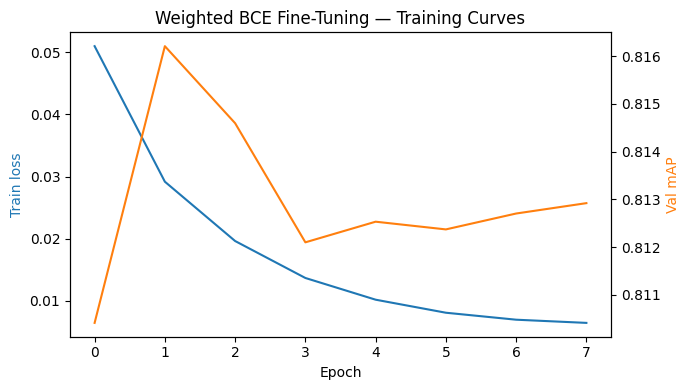


🏁 Weighted BCE Training Complete!
Best validation mAP: 0.8162
Baseline validation mAP (from Phase 2): 0.8113
Improvement: 0.0049

📂 Saved to: /kaggle/working/weighted_bce_run


In [26]:
# =============================================
# 🧪 Experiment: Weighted Binary Cross‑Entropy (BCE)
# =============================================

import os, json, random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification
from sklearn.metrics import average_precision_score
import matplotlib.pyplot as plt
import pandas as pd
import glob

# --- Set seed ---
SEED = 42
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed(SEED)

# --- Paths ---
CSV_PATH = "/kaggle/input/datasets/shuvrosankar/ladi-v2-csv-only"
IMAGE_ROOT = "/kaggle/input/datasets/shuvrosankar/ladi-v2-resized-images-reduced/ladi_dataset"
MODEL_CACHE = "/kaggle/input/datasets/shuvrosankar/model-cache/model_cache"

print("📁 CSV files:", os.listdir(CSV_PATH))
print("📁 Images found:", len(glob.glob(f"{IMAGE_ROOT}/**/*.jpg", recursive=True)) + len(glob.glob(f"{IMAGE_ROOT}/**/*.JPG", recursive=True)))

# --- Detect filename column ---
_peek = pd.read_csv(f"{CSV_PATH}/ladi_v2a_labels_train_resized.csv")
FILENAME_COL = 'local_path' if 'local_path' in _peek.columns else 'filename'
print(f"✅ Using '{FILENAME_COL}' as image filename column.\n")

# --- Config ---
CONFIG = {
    "seed": SEED,
    "loss": "WeightedBCE",
    "epochs": 8,
    "batch_size": 32,
    "lr": 1e-5,
    "weight_decay": 1e-4,
}
OUT_DIR = Path("/kaggle/working/weighted_bce_run")
OUT_DIR.mkdir(exist_ok=True)

# --- Device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using {device}\n")

# --- Model and Processor ---
processor = AutoImageProcessor.from_pretrained(MODEL_CACHE, use_fast=False)
model = AutoModelForImageClassification.from_pretrained(MODEL_CACHE).to(device)
label2id = {k: int(v) for k, v in model.config.label2id.items()}
class_names = list(label2id.keys())
print(f"✅ Model loaded with {model.config.num_labels} classes\n")

# --- Dataset ---
class LadiDataset(Dataset):
    def __init__(self, csv_path, image_dir, processor, label2id, filename_col="local_path"):
        self.df = pd.read_csv(csv_path)
        self.image_dir = Path(image_dir)
        self.processor = processor
        self.label2id = label2id
        self.num_classes = len(label2id)
        self.filename_col = filename_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        filename = row[self.filename_col].replace('#', '_')  # sanitize
        img = Image.open(self.image_dir / filename).convert("RGB")
        pixel_values = self.processor(img, return_tensors="pt")["pixel_values"][0]
        label = torch.zeros(self.num_classes, dtype=torch.float32)
        for cls_name, cls_idx in self.label2id.items():
            if cls_name in row.index and bool(row[cls_name]):
                label[cls_idx] = 1.0
        return pixel_values, label

# --- DataLoaders ---
train_ds = LadiDataset(f"{CSV_PATH}/ladi_v2a_labels_train_resized.csv", IMAGE_ROOT, processor, label2id, FILENAME_COL)
val_ds   = LadiDataset(f"{CSV_PATH}/ladi_v2a_labels_val_resized.csv", IMAGE_ROOT, processor, label2id, FILENAME_COL)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=2)

print(f"Train samples: {len(train_ds)}")
print(f"Val samples:   {len(val_ds)}\n")

# --- 🔥 THE KEY CHANGE: Weighted BCE Loss ---
class_counts = train_ds.df[class_names].sum().values
weights = 1.0 / torch.tensor(class_counts, dtype=torch.float32)
weights = weights / weights.sum() * len(weights)  # normalize so mean ≈ 1

criterion = nn.BCEWithLogitsLoss(pos_weight=weights.to(device))
print(f"✅ Weighted BCE loss initialized (weights: {weights.tolist()})\n")

# --- Optimizer and Scheduler ---
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# --- Evaluation function ---
def compute_map(y_true, y_score):
    aps = []
    for c in range(y_true.shape[1]):
        if y_true[:, c].sum() > 0:
            aps.append(average_precision_score(y_true[:, c], y_score[:, c]))
    valid = [a for a in aps if not np.isnan(a)]
    return float(np.mean(valid)), aps

def evaluate(model, loader, device):
    model.eval()
    all_targets, all_scores = [], []
    with torch.no_grad():
        for pixel_values, targets in loader:
            pixel_values = pixel_values.to(device)
            logits = model(pixel_values=pixel_values).logits
            all_scores.append(torch.sigmoid(logits).cpu().numpy())
            all_targets.append(targets.numpy())
    y_true = np.concatenate(all_targets)
    y_score = np.concatenate(all_scores)
    return compute_map(y_true, y_score)

# --- Training Loop ---
print("🏋️ Starting training...\n")
history = {"train_loss": [], "val_mAP": []}
best_map = -1.0

for epoch in range(CONFIG["epochs"]):
    model.train()
    running_loss = 0.0
    for pixel_values, targets in train_loader:
        pixel_values, targets = pixel_values.to(device), targets.to(device)
        optimizer.zero_grad()
        logits = model(pixel_values=pixel_values).logits
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * pixel_values.size(0)

    scheduler.step()
    epoch_loss = running_loss / len(train_ds)
    val_map, _ = evaluate(model, val_loader, device)

    history["train_loss"].append(epoch_loss)
    history["val_mAP"].append(val_map)
    print(f"Epoch {epoch+1}/{CONFIG['epochs']} — loss {epoch_loss:.4f} — val mAP {val_map:.4f}")

    torch.save(model.state_dict(), OUT_DIR / f"checkpoint_epoch{epoch+1}.pt")
    if val_map > best_map:
        best_map = val_map
        torch.save(model.state_dict(), OUT_DIR / "best_model.pt")

# --- Save results ---
with open(OUT_DIR / "config.json", "w") as f:
    json.dump(CONFIG, f, indent=2)
with open(OUT_DIR / "history.json", "w") as f:
    json.dump(history, f, indent=2)

# --- Plot training curves ---
fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(history["train_loss"], color="tab:blue", label="Train loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Train loss", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(history["val_mAP"], color="tab:orange", label="Val mAP")
ax2.set_ylabel("Val mAP", color="tab:orange")
plt.title("Weighted BCE Fine-Tuning — Training Curves")
fig.tight_layout()
fig.savefig(OUT_DIR / "training_curves.png", dpi=150)
plt.show()

# --- Final ---
print("\n" + "="*60)
print("🏁 Weighted BCE Training Complete!")
print("="*60)
print(f"Best validation mAP: {best_map:.4f}")
print(f"Baseline validation mAP (from Phase 2): 0.8113")
print(f"Improvement: {best_map - 0.8113:.4f}")
print(f"\n📂 Saved to: {OUT_DIR.resolve()}")

In [30]:
import os
dir_path = "/kaggle/working/weighted_bce_run"

if os.path.exists(dir_path):
    print("✅ Directory exists. Contents:")
    for f in os.listdir(dir_path):
        size = os.path.getsize(os.path.join(dir_path, f)) / (1024**2)
        print(f"  {f} ({size:.2f} MB)")
else:
    print("❌ Directory does NOT exist. You must re-train.")

✅ Directory exists. Contents:
  config.json (0.00 MB)
  checkpoint_epoch6.pt (89.80 MB)
  checkpoint_epoch5.pt (89.80 MB)
  training_curves.png (0.06 MB)
  best_model.pt (89.80 MB)
  history.json (0.00 MB)
  checkpoint_epoch7.pt (89.80 MB)
  checkpoint_epoch8.pt (89.80 MB)
  checkpoint_epoch2.pt (89.80 MB)
  checkpoint_epoch4.pt (89.80 MB)
  checkpoint_epoch3.pt (89.80 MB)
  checkpoint_epoch1.pt (89.80 MB)


In [31]:
import torch
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from transformers import AutoImageProcessor, AutoModelForImageClassification
from sklearn.metrics import average_precision_score
import shutil

# --- Paths ---
CSV_PATH = "/kaggle/input/datasets/shuvrosankar/ladi-v2-csv-only"
IMAGE_ROOT = "/kaggle/input/datasets/shuvrosankar/ladi-v2-resized-images-reduced/ladi_dataset"
MODEL_CACHE = "/kaggle/input/datasets/shuvrosankar/model-cache/model_cache"
OUT_DIR_BCE = Path("/kaggle/working/weighted_bce_run")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using {device}")

# --- 1. Load model and processor ---
processor = AutoImageProcessor.from_pretrained(MODEL_CACHE, use_fast=False)
model = AutoModelForImageClassification.from_pretrained(MODEL_CACHE).to(device)
model.load_state_dict(torch.load(OUT_DIR_BCE / "best_model.pt", map_location=device))
model.to(device).eval()
print("✅ Weighted BCE model loaded.")

# --- 2. Re‑create test loader ---
class LadiTestDataset(Dataset):
    def __init__(self, csv_path, image_dir, processor, label2id, filename_col="local_path"):
        self.df = pd.read_csv(csv_path)
        self.image_dir = Path(image_dir)
        self.processor = processor
        self.label2id = {k: int(v) for k, v in label2id.items()}
        self.num_classes = len(self.label2id)
        self.filename_col = filename_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        filename = row[self.filename_col].replace('#', '_')  # sanitize
        img = Image.open(self.image_dir / filename).convert("RGB")
        pixel_values = self.processor(img, return_tensors="pt")["pixel_values"][0]
        label = torch.zeros(self.num_classes, dtype=torch.float32)
        for cls_name, cls_idx in self.label2id.items():
            if cls_name in row.index and bool(row[cls_name]):
                label[cls_idx] = 1.0
        return pixel_values, label

label2id = model.config.label2id
test_csv = f"{CSV_PATH}/ladi_v2a_labels_test_resized.csv"
test_ds = LadiTestDataset(test_csv, IMAGE_ROOT, processor, label2id)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)
print(f"✅ Test loader created – {len(test_ds)} samples.")

# --- 3. Re‑define get_raw_scores if missing ---
def get_raw_scores(m, loader, device):
    m.eval()
    all_targets, all_scores = [], []
    with torch.no_grad():
        for pixel_values, targets in loader:
            pixel_values = pixel_values.to(device)
            logits = m(pixel_values=pixel_values).logits
            all_scores.append(torch.sigmoid(logits).cpu().numpy())
            all_targets.append(targets.numpy())
    return np.concatenate(all_targets), np.concatenate(all_scores)

# --- 4. Compute scores for Weighted BCE ---
_, wbce_scores = get_raw_scores(model, test_loader, device)
np.save(OUT_DIR_BCE / "wbce_scores.npy", wbce_scores)
print("✅ wbce_scores computed and saved.")

# --- 5. Create backup zip ---
shutil.make_archive("/kaggle/working/weighted_bce_backup", "zip", OUT_DIR_BCE)
print("✅ Backup zip created: weighted_bce_backup.zip")

# --- 6. Compute reference scores (if not already in memory) ---
ref_model = AutoModelForImageClassification.from_pretrained(MODEL_CACHE).to(device).eval()
y_true, ref_scores = get_raw_scores(ref_model, test_loader, device)
print("✅ Reference scores computed.")

# --- 7. Compare mAP ---
ref_map = np.mean([average_precision_score(y_true[:, i], ref_scores[:, i]) for i in range(12) if y_true[:, i].sum() > 0])
wbce_map = np.mean([average_precision_score(y_true[:, i], wbce_scores[:, i]) for i in range(12) if y_true[:, i].sum() > 0])

print("\n" + "="*60)
print("📊 Test mAP Comparison")
print("="*60)
print(f"Reference (baseline)          : {ref_map:.4f}")
print(f"Weighted BCE (this run)       : {wbce_map:.4f}")
print(f"Improvement over baseline     : {wbce_map - ref_map:+.4f}")
print("="*60)

# --- 8. Per-class breakdown for target classes ---
target_classes = ["roads_damage", "buildings_minor_or_greater", "flooding_structures", "bridges_any", "trees_damage"]
print(f"\n{'Class':<30}{'Baseline':>10}{'Weighted BCE':>14}")
for c in target_classes:
    idx = int(label2id[c])
    b = average_precision_score(y_true[:, idx], ref_scores[:, idx])
    w = average_precision_score(y_true[:, idx], wbce_scores[:, idx])
    print(f"{c:<30}{b:>10.4f}{w:>14.4f}")

print("\n📥 Download 'weighted_bce_backup.zip' from the Output panel now!")

✅ Using cuda


Loading weights:   0%|          | 0/153 [00:00<?, ?it/s]

✅ Weighted BCE model loaded.
✅ Test loader created – 1163 samples.
✅ wbce_scores computed and saved.
✅ Backup zip created: weighted_bce_backup.zip


Loading weights:   0%|          | 0/153 [00:00<?, ?it/s]

✅ Reference scores computed.

📊 Test mAP Comparison
Reference (baseline)          : 0.6114
Weighted BCE (this run)       : 0.6132
Improvement over baseline     : +0.0018

Class                           Baseline  Weighted BCE
roads_damage                      0.3241        0.2619
buildings_minor_or_greater        0.3779        0.4154
flooding_structures               0.3956        0.3800
bridges_any                       0.4129        0.4250
trees_damage                      0.4352        0.4586

📥 Download 'weighted_bce_backup.zip' from the Output panel now!


In [32]:
import os
print("📁 Contents of /kaggle/working/:")
for f in os.listdir("/kaggle/working"):
    size = os.path.getsize(os.path.join("/kaggle/working", f)) / (1024**2)
    print(f"  {f} ({size:.2f} MB)")

📁 Contents of /kaggle/working/:
  .virtual_documents (0.00 MB)
  focal_run_v2_backup.zip (1332.96 MB)
  weighted_bce_backup.zip (749.87 MB)
  focal_loss_run (0.00 MB)
  weighted_bce_run (0.00 MB)
  focal_loss_run_v2 (0.00 MB)


In [34]:
from IPython.display import HTML
import os

file_path = "/kaggle/working/weighted_bce_backup.zip"

if os.path.exists(file_path):
    size_gb = os.path.getsize(file_path) / (1024**3)
    display(HTML(f'<a href="{file_path}" download="weighted_bce_backup.zip">📥 Click here to download the backup zip ({size_gb:.2f} GB)</a>'))
    print("If it opens in a new tab with gibberish, right-click the link and select 'Save link as...'")
else:
    print("❌ File not found.")

If it opens in a new tab with gibberish, right-click the link and select 'Save link as...'


In [35]:
import os
import subprocess

file_path = "/kaggle/working/weighted_bce_backup.zip"
chunk_prefix = "/kaggle/working/backup_chunk_"

if os.path.exists(file_path):
    # Split into 200 MB chunks (200 * 1024 * 1024 bytes)
    subprocess.run(f"split -b 200M {file_path} {chunk_prefix}", shell=True)
    print("✅ File split into 200 MB chunks.")
    
    # List the chunks
    print("\n📁 Chunks created:")
    for f in sorted(os.listdir("/kaggle/working")):
        if f.startswith("backup_chunk_"):
            size_mb = os.path.getsize(os.path.join("/kaggle/working", f)) / (1024**2)
            print(f"  {f} ({size_mb:.1f} MB)")
else:
    print("❌ File not found.")

✅ File split into 200 MB chunks.

📁 Chunks created:
  backup_chunk_aa (200.0 MB)
  backup_chunk_ab (200.0 MB)
  backup_chunk_ac (200.0 MB)
  backup_chunk_ad (149.9 MB)


📁 CSV files: ['ladi_v2a_labels_train_resized.csv', 'ladi_v2a_labels_val_resized.csv', 'ladi_v2_labels_train_resized.csv', 'ladi_v2a_labels_train_full_resized.csv', 'ladi_v2_labels_train_full_resized.csv', 'ladi_v2_labels_val_resized.csv', 'ladi_v2a_labels_test_resized.csv', 'ladi_v2_labels_test_resized.csv']
📁 Images found: 9972
✅ Using 'local_path' as image filename column.

✅ Using cuda

⏳ Loading BiT-50...


Loading weights:   0%|          | 0/153 [00:00<?, ?it/s]

✅ Model loaded with 12 classes

Train samples: 8030
Val samples:   893

✅ Weighted BCE initialized.

🏋️ Starting training...

Epoch 1/8 — loss 0.0870 — val mAP 0.8001
Epoch 2/8 — loss 0.0630 — val mAP 0.7987
Epoch 3/8 — loss 0.0558 — val mAP 0.7943
Epoch 4/8 — loss 0.0508 — val mAP 0.7968
Epoch 5/8 — loss 0.0471 — val mAP 0.7964
Epoch 6/8 — loss 0.0441 — val mAP 0.7955
Epoch 7/8 — loss 0.0430 — val mAP 0.7955
Epoch 8/8 — loss 0.0416 — val mAP 0.7955


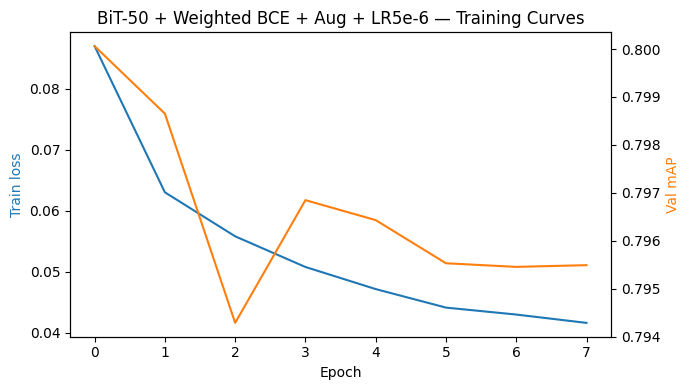


🏁 Training Complete!
Best validation mAP: 0.8001
Baseline validation mAP (from Phase 2): 0.8113
Improvement: -0.0112

📂 Saved to: /kaggle/working/bit_bce_aug_lr5e6_run


In [36]:
# =============================================
# 🔄 Experiment: BiT-50 + Weighted BCE + Augmentation + Lower LR
# =============================================

import os, json, random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification
from sklearn.metrics import average_precision_score
import matplotlib.pyplot as plt
import pandas as pd
import glob
from torchvision import transforms

# --- Set seed ---
SEED = 42
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed(SEED)

# --- Paths ---
CSV_PATH = "/kaggle/input/datasets/shuvrosankar/ladi-v2-csv-only"
IMAGE_ROOT = "/kaggle/input/datasets/shuvrosankar/ladi-v2-resized-images-reduced/ladi_dataset"
MODEL_CACHE = "/kaggle/input/datasets/shuvrosankar/model-cache/model_cache"

print("📁 CSV files:", os.listdir(CSV_PATH))
print("📁 Images found:", len(glob.glob(f"{IMAGE_ROOT}/**/*.jpg", recursive=True)) + len(glob.glob(f"{IMAGE_ROOT}/**/*.JPG", recursive=True)))

# --- Detect filename column ---
_peek = pd.read_csv(f"{CSV_PATH}/ladi_v2a_labels_train_resized.csv")
FILENAME_COL = 'local_path' if 'local_path' in _peek.columns else 'filename'
print(f"✅ Using '{FILENAME_COL}' as image filename column.\n")

# --- Config ---
CONFIG = {
    "seed": SEED,
    "backbone": "BiT-50",
    "loss": "WeightedBCE",
    "epochs": 8,
    "batch_size": 32,
    "lr": 5e-6,                # lower than previous 1e-5
    "weight_decay": 1e-4,
    "augmentation": True,
}
OUT_DIR = Path("/kaggle/working/bit_bce_aug_lr5e6_run")
OUT_DIR.mkdir(exist_ok=True)

# --- Device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using {device}\n")

# --- Load BiT-50 model from local cache ---
print("⏳ Loading BiT-50...")
processor = AutoImageProcessor.from_pretrained(MODEL_CACHE, use_fast=False)
model = AutoModelForImageClassification.from_pretrained(MODEL_CACHE).to(device)
label2id = {k: int(v) for k, v in model.config.label2id.items()}
class_names = list(label2id.keys())
print(f"✅ Model loaded with {model.config.num_labels} classes\n")

# --- Data Augmentation transforms ---
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05),
    transforms.Resize((224, 224)),  # ensure size
])

# --- Dataset with optional augmentation ---
class LadiDataset(Dataset):
    def __init__(self, csv_path, image_dir, processor, label2id, filename_col="local_path", augment=False):
        self.df = pd.read_csv(csv_path)
        self.image_dir = Path(image_dir)
        self.processor = processor
        self.label2id = label2id
        self.num_classes = len(label2id)
        self.filename_col = filename_col
        self.augment = augment
        if augment:
            self.transform = train_transform
        else:
            self.transform = None

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        filename = row[self.filename_col].replace('#', '_')
        img = Image.open(self.image_dir / filename).convert("RGB")
        if self.transform:
            img = self.transform(img)
        pixel_values = self.processor(img, return_tensors="pt")["pixel_values"][0]
        label = torch.zeros(self.num_classes, dtype=torch.float32)
        for cls_name, cls_idx in self.label2id.items():
            if cls_name in row.index and bool(row[cls_name]):
                label[cls_idx] = 1.0
        return pixel_values, label

# --- DataLoaders ---
train_ds = LadiDataset(f"{CSV_PATH}/ladi_v2a_labels_train_resized.csv", IMAGE_ROOT, processor, label2id, FILENAME_COL, augment=True)
val_ds   = LadiDataset(f"{CSV_PATH}/ladi_v2a_labels_val_resized.csv", IMAGE_ROOT, processor, label2id, FILENAME_COL, augment=False)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=2)

print(f"Train samples: {len(train_ds)}")
print(f"Val samples:   {len(val_ds)}\n")

# --- Weighted BCE Loss ---
class_counts = train_ds.df[class_names].sum().values
weights = 1.0 / torch.tensor(class_counts, dtype=torch.float32)
weights = weights / weights.sum() * len(weights)
criterion = nn.BCEWithLogitsLoss(pos_weight=weights.to(device))
print(f"✅ Weighted BCE initialized.\n")

# --- Optimizer and Scheduler ---
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# --- Evaluation ---
def compute_map(y_true, y_score):
    aps = []
    for c in range(y_true.shape[1]):
        if y_true[:, c].sum() > 0:
            aps.append(average_precision_score(y_true[:, c], y_score[:, c]))
    valid = [a for a in aps if not np.isnan(a)]
    return float(np.mean(valid)), aps

def evaluate(model, loader, device):
    model.eval()
    all_targets, all_scores = [], []
    with torch.no_grad():
        for pixel_values, targets in loader:
            pixel_values = pixel_values.to(device)
            logits = model(pixel_values=pixel_values).logits
            all_scores.append(torch.sigmoid(logits).cpu().numpy())
            all_targets.append(targets.numpy())
    y_true = np.concatenate(all_targets)
    y_score = np.concatenate(all_scores)
    return compute_map(y_true, y_score)

# --- Training Loop ---
print("🏋️ Starting training...\n")
history = {"train_loss": [], "val_mAP": []}
best_map = -1.0

for epoch in range(CONFIG["epochs"]):
    model.train()
    running_loss = 0.0
    for pixel_values, targets in train_loader:
        pixel_values, targets = pixel_values.to(device), targets.to(device)
        optimizer.zero_grad()
        logits = model(pixel_values=pixel_values).logits
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * pixel_values.size(0)

    scheduler.step()
    epoch_loss = running_loss / len(train_ds)
    val_map, _ = evaluate(model, val_loader, device)

    history["train_loss"].append(epoch_loss)
    history["val_mAP"].append(val_map)
    print(f"Epoch {epoch+1}/{CONFIG['epochs']} — loss {epoch_loss:.4f} — val mAP {val_map:.4f}")

    torch.save(model.state_dict(), OUT_DIR / f"checkpoint_epoch{epoch+1}.pt")
    if val_map > best_map:
        best_map = val_map
        torch.save(model.state_dict(), OUT_DIR / "best_model.pt")

# --- Save results ---
with open(OUT_DIR / "config.json", "w") as f:
    json.dump(CONFIG, f, indent=2)
with open(OUT_DIR / "history.json", "w") as f:
    json.dump(history, f, indent=2)

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(history["train_loss"], color="tab:blue", label="Train loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Train loss", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(history["val_mAP"], color="tab:orange", label="Val mAP")
ax2.set_ylabel("Val mAP", color="tab:orange")
plt.title("BiT-50 + Weighted BCE + Aug + LR5e-6 — Training Curves")
fig.tight_layout()
fig.savefig(OUT_DIR / "training_curves.png", dpi=150)
plt.show()

# --- Final ---
print("\n" + "="*60)
print("🏁 Training Complete!")
print("="*60)
print(f"Best validation mAP: {best_map:.4f}")
print(f"Baseline validation mAP (from Phase 2): 0.8113")
print(f"Improvement: {best_map - 0.8113:.4f}")
print(f"\n📂 Saved to: {OUT_DIR.resolve()}")

In [41]:
import shutil
shutil.make_archive("/kaggle/working/bit_bce_aug_backup", "zip", OUT_DIR)
print("✅ Backup zip created.")

✅ Backup zip created.


In [42]:
import re, pandas as pd

df_val  = pd.read_csv(f"{CSV_PATH}/ladi_v2a_labels_val_resized.csv")
df_test = pd.read_csv(f"{CSV_PATH}/ladi_v2a_labels_test_resized.csv")

def get_source(url):
    m = re.search(r'/Images/([^/]+)/', str(url))
    return m.group(1) if m else "unknown"

if "url" in df_val.columns:
    df_val["source"]  = df_val["url"].apply(get_source)
    df_test["source"] = df_test["url"].apply(get_source)

    val_sources  = set(df_val["source"].unique())
    test_sources = set(df_test["source"].unique())

    print(f"Val sources:  {len(val_sources)}")
    print(f"Test sources: {len(test_sources)}")
    print(f"Shared:       {len(val_sources & test_sources)}")
    print(f"Test-only:    {len(test_sources - val_sources)}")
    print()
    print("Top test sources NOT seen in val:")
    print(df_test[~df_test["source"].isin(val_sources)]["source"].value_counts().head(10))
else:
    print("No 'url' column — fall back to Cell 2 (visual/stat comparison) instead.")

Val sources:  46
Test sources: 7
Shared:       0
Test-only:    7

Top test sources NOT seen in val:
source
CAP_-_PA_Storms_Aug_2023       200
CAP_-_AR_Storms_APR_2023       185
CAP_-_VT_Flooding_Jul_2023     169
CAP_-_MS_Tornadoes_MAR_2023    165
CAP_-_HI_Wildfires_Aug_2023    162
CAP_-_CA_Storms_Jan_2023       149
CAP_-_Hur_Idalia_Aug_2023      133
Name: count, dtype: int64


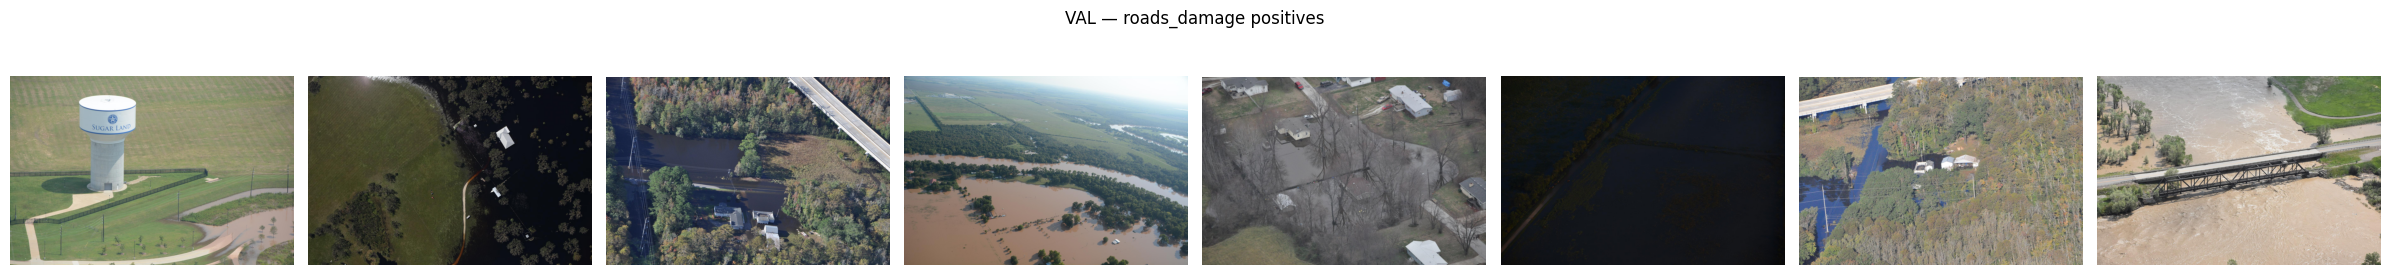

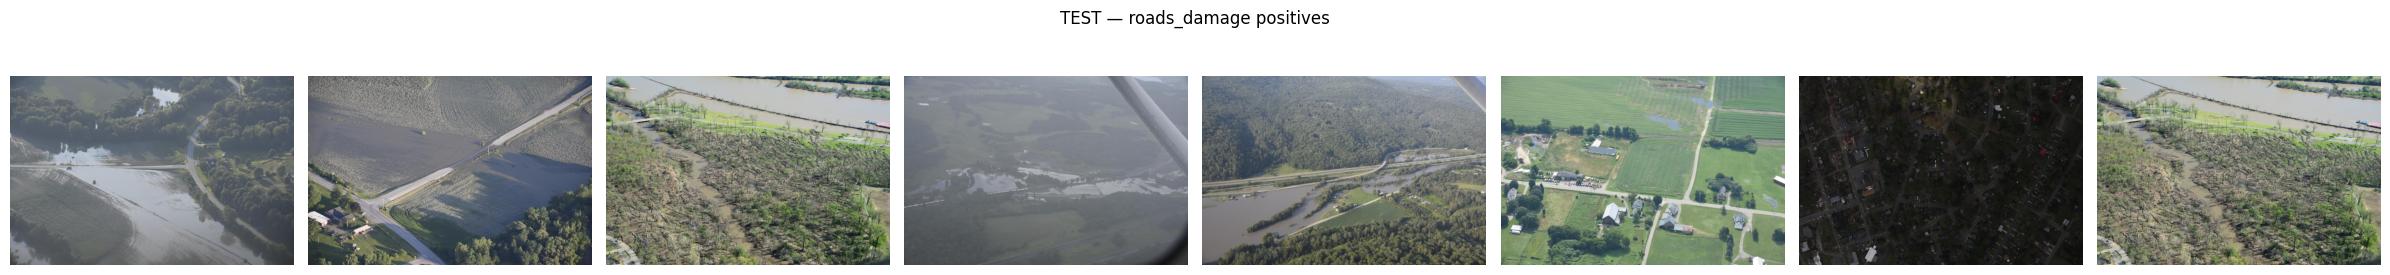

In [39]:
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

def show_class_grid(df, cls, n=8, title=""):
    rows = df[df[cls] == 1].sample(min(n, df[cls].sum()), random_state=42)
    fig, axes = plt.subplots(1, len(rows), figsize=(3*len(rows), 3))
    if len(rows) == 1: axes = [axes]
    for ax, (_, row) in zip(axes, rows.iterrows()):
        filename = str(row[FILENAME_COL]).replace("#", "_")
        img = Image.open(Path(IMAGE_ROOT) / row[FILENAME_COL]).convert("RGB")
        ax.imshow(img); ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout(); plt.show()

show_class_grid(df_val,  "roads_damage", title="VAL — roads_damage positives")
show_class_grid(df_test, "roads_damage", title="TEST — roads_damage positives")

In [43]:
import numpy as np

def image_stats(df, n=200):
    sample = df.sample(min(n, len(df)), random_state=42)
    sizes, brightness = [], []
    for _, row in sample.iterrows():
        filename = str(row[FILENAME_COL]).replace("#", "_")
        img = Image.open(Path(IMAGE_ROOT) / row[FILENAME_COL]).convert("RGB")
        sizes.append(img.size)
        brightness.append(np.array(img).mean())
    widths, heights = zip(*sizes)
    return {
        "mean_width": np.mean(widths), "mean_height": np.mean(heights),
        "mean_brightness": np.mean(brightness),
    }

print("Val: ", image_stats(df_val))
print("Test:", image_stats(df_test))

Val:  {'mean_width': np.float64(1797.785), 'mean_height': np.float64(1199.44), 'mean_brightness': np.float64(91.71265287521398)}
Test: {'mean_width': np.float64(1799.98), 'mean_height': np.float64(1199.055), 'mean_brightness': np.float64(104.308741223061)}


In [44]:
df_train = pd.read_csv(f"{CSV_PATH}/ladi_v2a_labels_train_resized.csv")
df_train["source"] = df_train["url"].apply(get_source)
print("Train ∩ test:", len(set(df_train["source"]) & test_sources))

Train ∩ test: 0


In [47]:
from sklearn.model_selection import GroupShuffleSplit

def make_event_holdout_split(df, group_col="source", val_frac=0.15, seed=42):
    """Re-splits train+val by EVENT instead of by image, so the new val set
    contains disaster events the new train set has never seen — mirroring
    the real train/test relationship you just confirmed, instead of the
    original random image-level split.
    """
    splitter = GroupShuffleSplit(n_splits=1, test_size=val_frac, random_state=seed)
    train_idx, val_idx = next(splitter.split(df, groups=df[group_col]))
    df_train_new = df.iloc[train_idx].reset_index(drop=True)
    df_val_new = df.iloc[val_idx].reset_index(drop=True)

    overlap = set(df_train_new[group_col]) & set(df_val_new[group_col])
    assert len(overlap) == 0, f"Leakage! shared events: {overlap}"

    print(f"New train: {len(df_train_new)} images, {df_train_new[group_col].nunique()} events")
    print(f"New val:   {len(df_val_new)} images, {df_val_new[group_col].nunique()} events")
    return df_train_new, df_val_new


def check_class_coverage(df_train_new, df_val_new, label_columns):
    """Rare classes (bridges_any, debris_any, roads_damage...) may be
    concentrated in just a handful of events — a bad re-split could
    accidentally zero one out of val entirely."""
    rows = [{"class": c,
             "train_pos": int(df_train_new[c].sum()),
             "val_pos": int(df_val_new[c].sum())} for c in label_columns]
    out = pd.DataFrame(rows)
    zero_val = out[out["val_pos"] == 0]["class"].tolist()
    if zero_val:
        print(f"⚠️  Zero positives in new val for: {zero_val} — try a different seed.")
    print(out.to_string(index=False))
    return out

In [48]:
df_train = pd.read_csv(f"{CSV_PATH}/ladi_v2a_labels_train_resized.csv")
df_val   = pd.read_csv(f"{CSV_PATH}/ladi_v2a_labels_val_resized.csv")
df_pool = pd.concat([df_train, df_val], ignore_index=True)
df_pool["source"] = df_pool["url"].apply(get_source)

label_columns = [c for c in df_pool.columns if c not in ("url", "local_path", "source")]

df_train_new, df_val_new = make_event_holdout_split(df_pool, val_frac=0.15, seed=42)
check_class_coverage(df_train_new, df_val_new, label_columns)

New train: 8164 images, 53 events
New val:   759 images, 10 events
                        class  train_pos  val_pos
                  bridges_any        551       73
                buildings_any       4769      522
buildings_affected_or_greater       1499      171
   buildings_minor_or_greater        467       75
                   debris_any        666       97
                 flooding_any       1442      179
          flooding_structures        441       58
                    roads_any       5308      564
                 roads_damage        345       62
                    trees_any       7331      735
                 trees_damage       2003      190
                    water_any       5402      455


,class,train_pos,val_pos
0,bridges_any,551,73
1,buildings_any,4769,522
2,buildings_affected_or_greater,1499,171
3,buildings_minor_or_greater,467,75
4,debris_any,666,97
5,flooding_any,1442,179
6,flooding_structures,441,58
7,roads_any,5308,564
8,roads_damage,345,62
9,trees_any,7331,735


In [52]:
class LadiDataset(Dataset):
    def __init__(self, csv_or_df, image_dir, processor, label2id, filename_col="local_path"):
        self.df = csv_or_df if isinstance(csv_or_df, pd.DataFrame) else pd.read_csv(csv_or_df)
        self.image_dir = Path(image_dir)
        self.processor = processor
        self.label2id = label2id
        self.num_classes = len(label2id)
        self.filename_col = filename_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        filename = row[self.filename_col].replace('#', '_')  # sanitize
        img = Image.open(self.image_dir / filename).convert("RGB")
        pixel_values = self.processor(img, return_tensors="pt")["pixel_values"][0]
        label = torch.zeros(self.num_classes, dtype=torch.float32)
        for cls_name, cls_idx in self.label2id.items():
            if cls_name in row.index and bool(row[cls_name]):
                label[cls_idx] = 1.0
        return pixel_values, label

In [53]:
train_ds = LadiDataset(df_train_new, IMAGE_ROOT, processor, label2id)
val_ds   = LadiDataset(df_val_new,   IMAGE_ROOT, processor, label2id)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=CONFIG["batch_size"], shuffle=False, num_workers=2)

In [54]:
# --- Config for this run ---
CONFIG = {
    "seed": SEED,
    "loss": "WeightedBCE",
    "epochs": 8,
    "batch_size": 32,
    "lr": 1e-5,
    "weight_decay": 1e-4,
}
OUT_DIR = Path("/kaggle/working/weighted_bce_event_holdout_run")
OUT_DIR.mkdir(exist_ok=True)

# --- Reload a FRESH copy of the baseline model ---
# If `model` was already fine-tuned earlier in this session, reusing it here
# would start training from those weights instead of the baseline — reload
# from MODEL_CACHE so this run is a clean, comparable experiment.
model = AutoModelForImageClassification.from_pretrained(MODEL_CACHE).to(device)
class_names = list(label2id.keys())

# --- Weighted BCE loss, computed from the NEW train split ---
class_counts = train_ds.df[class_names].sum().values
weights = 1.0 / torch.tensor(class_counts, dtype=torch.float32)
weights = weights / weights.sum() * len(weights)
criterion = nn.BCEWithLogitsLoss(pos_weight=weights.to(device))
print(f"✅ Weighted BCE loss initialized (weights: {weights.tolist()})\n")

# --- Optimizer & scheduler ---
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# --- Eval helpers ---
def compute_map(y_true, y_score):
    aps = []
    for c in range(y_true.shape[1]):
        if y_true[:, c].sum() > 0:
            aps.append(average_precision_score(y_true[:, c], y_score[:, c]))
    valid = [a for a in aps if not np.isnan(a)]
    return float(np.mean(valid)), aps

def evaluate(model, loader, device):
    model.eval()
    all_targets, all_scores = [], []
    with torch.no_grad():
        for pixel_values, targets in loader:
            pixel_values = pixel_values.to(device)
            logits = model(pixel_values=pixel_values).logits
            all_scores.append(torch.sigmoid(logits).cpu().numpy())
            all_targets.append(targets.numpy())
    y_true = np.concatenate(all_targets)
    y_score = np.concatenate(all_scores)
    return compute_map(y_true, y_score)

# --- Training loop ---
print("🏋️ Starting training (event-holdout val)...\n")
history = {"train_loss": [], "val_mAP": []}
best_map = -1.0

for epoch in range(CONFIG["epochs"]):
    model.train()
    running_loss = 0.0
    for pixel_values, targets in train_loader:
        pixel_values, targets = pixel_values.to(device), targets.to(device)
        optimizer.zero_grad()
        logits = model(pixel_values=pixel_values).logits
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * pixel_values.size(0)

    scheduler.step()
    epoch_loss = running_loss / len(train_ds)
    val_map, _ = evaluate(model, val_loader, device)

    history["train_loss"].append(epoch_loss)
    history["val_mAP"].append(val_map)
    print(f"Epoch {epoch+1}/{CONFIG['epochs']} — loss {epoch_loss:.4f} — val mAP {val_map:.4f}")

    torch.save(model.state_dict(), OUT_DIR / f"checkpoint_epoch{epoch+1}.pt")
    if val_map > best_map:
        best_map = val_map
        torch.save(model.state_dict(), OUT_DIR / "best_model.pt")

print("\n" + "="*60)
print("🏁 Training Complete (event-holdout validation)!")
print("="*60)
print(f"Best event-holdout val mAP: {best_map:.4f}")

Loading weights:   0%|          | 0/153 [00:00<?, ?it/s]

✅ Weighted BCE loss initialized (weights: [1.649482250213623, 0.6063140034675598, 0.19057762622833252, 1.9461770057678223, 1.364661693572998, 0.6302806735038757, 2.060917615890503, 0.171225443482399, 2.634390354156494, 0.12397553026676178, 0.45375171303749084, 0.16824597120285034])

🏋️ Starting training (event-holdout val)...

Epoch 1/8 — loss 0.0658 — val mAP 0.9721
Epoch 2/8 — loss 0.0385 — val mAP 0.9734
Epoch 3/8 — loss 0.0257 — val mAP 0.9719
Epoch 4/8 — loss 0.0181 — val mAP 0.9712
Epoch 5/8 — loss 0.0134 — val mAP 0.9708
Epoch 6/8 — loss 0.0108 — val mAP 0.9706
Epoch 7/8 — loss 0.0093 — val mAP 0.9702
Epoch 8/8 — loss 0.0087 — val mAP 0.9701

🏁 Training Complete (event-holdout validation)!
Best event-holdout val mAP: 0.9734


In [55]:
def is_named_event(s):
    return not s.isdigit()

print("Held-out val sources (this run):")
print(sorted(df_val_new["source"].unique()))
print()

pool_types = df_pool["source"].drop_duplicates().apply(is_named_event).value_counts()
val_types  = df_val_new["source"].drop_duplicates().apply(is_named_event).value_counts()
print("Full pool  — named vs numeric sources:", pool_types.to_dict())
print("Held-out val — named vs numeric sources:", val_types.to_dict())

Held-out val sources (this run):
['1013', '2033', '3047', '7063', '9109', '9157', '9188', 'CAP_-_KY_Flooding_July_2022', 'CAP_-_TS_Nicole_Nov_2022', 'CAP_-_Testing']

Full pool  — named vs numeric sources: {False: 55, True: 8}
Held-out val — named vs numeric sources: {False: 7, True: 3}


In [56]:
testing_rows = df_pool[df_pool["source"] == "CAP_-_Testing"]
print(f"CAP_-_Testing: {len(testing_rows)} images")
print(testing_rows[class_names].sum())

CAP_-_Testing: 39 images
bridges_any                       2
buildings_affected_or_greater    24
buildings_any                    28
buildings_minor_or_greater       19
debris_any                       27
flooding_any                      7
flooding_structures               0
roads_any                        31
roads_damage                      1
trees_any                        37
trees_damage                     30
water_any                        36
dtype: int64


In [57]:
named_sources = [s for s in df_pool["source"].unique() if not s.isdigit()]
print(f"{len(named_sources)} named sources: {named_sources}\n")

rows = []
for s in named_sources:
    sub = df_pool[df_pool["source"] == s]
    row = {"source": s, "n_images": len(sub)}
    for c in class_names:
        row[c] = round(sub[c].mean(), 2)
    rows.append(row)

summary = pd.DataFrame(rows).set_index("source")
print(summary.to_string())

8 named sources: ['CAP_-_Hur_Ian_Sept_2022', 'CAP_-_MT_Floods_2022', 'STG_Test_10062022', 'CAP_-_KY_Flooding_July_2022', 'CAP_-_TS_Fiona_Sept_2022', 'CAP_-_TS_Nicole_Nov_2022', 'CAP_-_CA_SAR_22M0333A', 'CAP_-_Testing']

                             n_images  bridges_any  buildings_affected_or_greater  buildings_any  buildings_minor_or_greater  debris_any  flooding_any  flooding_structures  roads_any  roads_damage  trees_any  trees_damage  water_any
source                                                                                                                                                                                                                                  
CAP_-_Hur_Ian_Sept_2022          2108         0.02                           0.09           0.64                        0.01        0.02          0.06                 0.02       0.70          0.01       0.95          0.10       0.59
CAP_-_MT_Floods_2022                9         0.44                           0.00

In [58]:
CONTAMINATED_SOURCES = ["CAP_-_Testing", "STG_Test_10062022"]  # update after checking the table above
df_pool_clean = df_pool[~df_pool["source"].isin(CONTAMINATED_SOURCES)].reset_index(drop=True)
print(f"Removed {len(df_pool) - len(df_pool_clean)} images from {len(CONTAMINATED_SOURCES)} contaminated sources")

Removed 191 images from 2 contaminated sources


In [59]:
df_pool_clean = df_pool[df_pool["source"] != "CAP_-_Testing"].reset_index(drop=True)

In [61]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("device variable:", device)
print("model is on:", next(model.parameters()).device)

CUDA available: True
device variable: cuda
model is on: cuda:0


In [63]:
import time, json

TIME_BUDGET_SECONDS = 100 * 60   # leave ~20 min buffer under your ~2hr remaining
EPOCHS_PER_FOLD = 3              # cut from 8 — early-stops on best_map anyway
EST_MIN_PER_EPOCH = 5.5          # from your timing check; update if you tested use_fast

results_path = Path("/kaggle/working/leave_one_event_out_results.json")
fold_results = []
if results_path.exists():
    fold_results = json.loads(results_path.read_text())
    print(f"Resuming — {len(fold_results)} folds already done: {[r['held_out_event'] for r in fold_results]}")

completed_events = {r["held_out_event"] for r in fold_results}
start_time = time.time()

for held_out_event in HOLDOUT_CANDIDATE_EVENTS:
    if held_out_event in completed_events:
        continue

    elapsed = time.time() - start_time
    remaining = TIME_BUDGET_SECONDS - elapsed
    est_fold_time = EPOCHS_PER_FOLD * EST_MIN_PER_EPOCH * 60
    if remaining < est_fold_time:
        print(f"\n⏭️  Skipping remaining folds — only {remaining/60:.1f} min left, "
              f"need ~{est_fold_time/60:.1f} min for {held_out_event}")
        break

    print(f"\n{'='*60}\nFold: holding out {held_out_event}\n{'='*60}")
    val_mask = df_pool_clean["source"] == held_out_event
    df_train_fold = df_pool_clean[~val_mask].reset_index(drop=True)
    df_val_fold = df_pool_clean[val_mask].reset_index(drop=True)

    train_ds = LadiDataset(df_train_fold, IMAGE_ROOT, processor, label2id)
    val_ds   = LadiDataset(df_val_fold,   IMAGE_ROOT, processor, label2id)
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)

    model = AutoModelForImageClassification.from_pretrained(MODEL_CACHE).to(device)
    class_names = list(label2id.keys())
    class_counts = train_ds.df[class_names].sum().values
    weights = 1.0 / torch.tensor(class_counts, dtype=torch.float32)
    weights = weights / weights.sum() * len(weights)
    criterion = nn.BCEWithLogitsLoss(pos_weight=weights.to(device))
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_PER_FOLD)

    best_map = -1.0
    fold_t0 = time.time()
    for epoch in range(EPOCHS_PER_FOLD):
        model.train()
        for pixel_values, targets in tqdm(train_loader, desc=f"{held_out_event} ep{epoch+1}"):
            pixel_values, targets = pixel_values.to(device), targets.to(device)
            optimizer.zero_grad()
            logits = model(pixel_values=pixel_values).logits
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()
        scheduler.step()
        val_map, _ = evaluate(model, val_loader, device)
        best_map = max(best_map, val_map)
        print(f"  epoch {epoch+1}: val mAP {val_map:.4f}")

    fold_time = time.time() - fold_t0
    print(f"Best val mAP holding out {held_out_event}: {best_map:.4f} ({fold_time/60:.1f} min)")

    fold_results.append({
        "held_out_event": held_out_event,
        "n_val_images": len(df_val_fold),
        "best_val_mAP": best_map,
        "fold_minutes": round(fold_time / 60, 1),
    })
    results_path.write_text(json.dumps(fold_results, indent=2))  # save after EVERY fold

results_df = pd.DataFrame(fold_results)
print("\n" + "="*60 + "\nLEAVE-ONE-EVENT-OUT SUMMARY (so far)\n" + "="*60)
print(results_df.to_string(index=False))
if len(results_df) > 1:
    print(f"\nMean: {results_df['best_val_mAP'].mean():.4f}  |  Std: {results_df['best_val_mAP'].std():.4f}")


Fold: holding out CAP_-_Hur_Ian_Sept_2022


Loading weights:   0%|          | 0/153 [00:00<?, ?it/s]

CAP_-_Hur_Ian_Sept_2022 ep1:   0%|          | 0/212 [00:00<?, ?it/s]

  epoch 1: val mAP 0.9285


CAP_-_Hur_Ian_Sept_2022 ep2:   0%|          | 0/212 [00:00<?, ?it/s]

...

  epoch 1: val mAP 0.8346


CAP_-_TS_Nicole_Nov_2022 ep2:   0%|          | 0/274 [00:00<?, ?it/s]

  epoch 2: val mAP 0.7903


CAP_-_TS_Nicole_Nov_2022 ep3:   0%|          | 0/274 [00:00<?, ?it/s]

  epoch 3: val mAP 0.8175
Best val mAP holding out CAP_-_TS_Nicole_Nov_2022: 0.8346 (22.5 min)

⏭️  Skipping remaining folds — only 10.4 min left, need ~16.5 min for STG_Test_10062022

LEAVE-ONE-EVENT-OUT SUMMARY (so far)
             held_out_event  n_val_images  best_val_mAP  fold_minutes
    CAP_-_Hur_Ian_Sept_2022          2108      0.928518          22.4
CAP_-_KY_Flooding_July_2022           259      0.905449          21.8
   CAP_-_TS_Fiona_Sept_2022           326      0.929908          22.6
   CAP_-_TS_Nicole_Nov_2022           124      0.834561          22.5

Mean: 0.8996  |  Std: 0.0448


In [64]:
def get_scores(df, image_dir, processor, model, device, label2id, batch_size=32):
    ds = LadiDataset(df, image_dir, processor, label2id)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
    model.eval()
    scores = []
    with torch.no_grad():
        for pixel_values, _ in loader:
            pixel_values = pixel_values.to(device)
            logits = model(pixel_values=pixel_values).logits
            scores.append(torch.sigmoid(logits).cpu().numpy())
    return np.concatenate(scores)

def domain_shift_score(scores_a, scores_b, n_splits=3):
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import cross_val_score
    X = np.vstack([scores_a, scores_b])
    y = np.concatenate([np.zeros(len(scores_a)), np.ones(len(scores_b))])
    clf = LogisticRegression(max_iter=1000)
    aucs = cross_val_score(clf, X, y, cv=n_splits, scoring="roc_auc")
    return aucs

# clean, un-fine-tuned reference model for a fair comparison
model = AutoModelForImageClassification.from_pretrained(MODEL_CACHE).to(device)

# (a) two DIFFERENT 2022 events vs each other — mimics your completed CV folds
df_a = df_pool_clean[df_pool_clean["source"] == "CAP_-_TS_Fiona_Sept_2022"]
df_b = df_pool_clean[df_pool_clean["source"] == "CAP_-_KY_Flooding_July_2022"]
scores_a = get_scores(df_a, IMAGE_ROOT, processor, model, device, label2id)
scores_b = get_scores(df_b, IMAGE_ROOT, processor, model, device, label2id)
aucs_2022 = domain_shift_score(scores_a, scores_b)

# (b) whole 2022-era pool vs the real 2023 test set — mimics the actual val/test gap
scores_2022 = get_scores(df_pool_clean.sample(300, random_state=0), IMAGE_ROOT, processor, model, device, label2id)
scores_test = get_scores(df_test.sample(300, random_state=0), IMAGE_ROOT, processor, model, device, label2id)
aucs_real = domain_shift_score(scores_2022, scores_test)

print(f"2022-vs-2022 (different events) AUC: {aucs_2022.mean():.3f} ± {aucs_2022.std():.3f}")
print(f"2022-vs-2023 (real val/test relationship) AUC: {aucs_real.mean():.3f} ± {aucs_real.std():.3f}")

Loading weights:   0%|          | 0/153 [00:00<?, ?it/s]

2022-vs-2022 (different events) AUC: 0.856 ± 0.027
2022-vs-2023 (real val/test relationship) AUC: 0.695 ± 0.007


In [2]:
import os
print(os.listdir("/kaggle/working"))

['.virtual_documents']


In [3]:
fold_results = [
    {"held_out_event": "CAP_-_Hur_Ian_Sept_2022", "n_val_images": 2108, "best_val_mAP": 0.928518},
    {"held_out_event": "CAP_-_KY_Flooding_July_2022", "n_val_images": 259, "best_val_mAP": 0.905449},
    {"held_out_event": "CAP_-_TS_Fiona_Sept_2022", "n_val_images": 326, "best_val_mAP": 0.929908},
    {"held_out_event": "CAP_-_TS_Nicole_Nov_2022", "n_val_images": 124, "best_val_mAP": 0.834561},
]

In [4]:
import os, json, random, glob
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification
from sklearn.metrics import average_precision_score
import pandas as pd
import re

# --- paths (from your original cell 6) ---
CSV_PATH = "/kaggle/input/datasets/shuvrosankar/ladi-v2-csv-only"
IMAGE_ROOT = "/kaggle/input/datasets/shuvrosankar/ladi-v2-resized-images-reduced/ladi_dataset"
MODEL_CACHE = "/kaggle/input/datasets/shuvrosankar/model-cache/model_cache"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

processor = AutoImageProcessor.from_pretrained(MODEL_CACHE, use_fast=False)
model = AutoModelForImageClassification.from_pretrained(MODEL_CACHE).to(device)
label2id = {k: int(v) for k, v in model.config.label2id.items()}
class_names = list(label2id.keys())
print(f"✅ Model loaded, {len(class_names)} classes")

# --- dataset class (with the '#' sanitize + DataFrame-or-path fix) ---
class LadiDataset(Dataset):
    def __init__(self, csv_or_df, image_dir, processor, label2id, filename_col="local_path"):
        self.df = csv_or_df if isinstance(csv_or_df, pd.DataFrame) else pd.read_csv(csv_or_df)
        self.image_dir = Path(image_dir)
        self.processor = processor
        self.label2id = label2id
        self.num_classes = len(label2id)
        self.filename_col = filename_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        filename = row[self.filename_col].replace('#', '_')
        img = Image.open(self.image_dir / filename).convert("RGB")
        pixel_values = self.processor(img, return_tensors="pt")["pixel_values"][0]
        label = torch.zeros(self.num_classes, dtype=torch.float32)
        for cls_name, cls_idx in self.label2id.items():
            if cls_name in row.index and bool(row[cls_name]):
                label[cls_idx] = 1.0
        return pixel_values, label

# --- eval helpers ---
def compute_map(y_true, y_score):
    aps = [average_precision_score(y_true[:, c], y_score[:, c])
           for c in range(y_true.shape[1]) if y_true[:, c].sum() > 0]
    return float(np.mean(aps)), aps

def evaluate(model, loader, device):
    model.eval()
    all_targets, all_scores = [], []
    with torch.no_grad():
        for pixel_values, targets in loader:
            pixel_values = pixel_values.to(device)
            logits = model(pixel_values=pixel_values).logits
            all_scores.append(torch.sigmoid(logits).cpu().numpy())
            all_targets.append(targets.numpy())
    return compute_map(np.concatenate(all_targets), np.concatenate(all_scores))

# --- rebuild df_pool_clean (train + val, event-tagged, contamination removed) ---
def get_source(url):
    m = re.search(r'/Images/([^/]+)/', str(url))
    return m.group(1) if m else "unknown"

df_train = pd.read_csv(f"{CSV_PATH}/ladi_v2a_labels_train_resized.csv")
df_val   = pd.read_csv(f"{CSV_PATH}/ladi_v2a_labels_val_resized.csv")
df_test  = pd.read_csv(f"{CSV_PATH}/ladi_v2a_labels_test_resized.csv")

df_pool = pd.concat([df_train, df_val], ignore_index=True)
df_pool["source"] = df_pool["url"].apply(get_source)
df_pool_clean = df_pool[df_pool["source"] != "CAP_-_Testing"].reset_index(drop=True)

print(f"df_pool_clean: {len(df_pool_clean)} images, {df_pool_clean['source'].nunique()} sources")
print(f"df_test: {len(df_test)} images")

device: cuda


Loading weights:   0%|          | 0/153 [00:00<?, ?it/s]

✅ Model loaded, 12 classes
df_pool_clean: 8884 images, 62 sources
df_test: 1163 images


In [5]:
def get_backbone_embeddings(df, image_dir, processor, model, device, batch_size=32):
    ds = LadiDataset(df, image_dir, processor, label2id)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
    model.eval()
    feats = []
    with torch.no_grad():
        for pixel_values, _ in loader:
            pixel_values = pixel_values.to(device)
            out = model.base_model(pixel_values=pixel_values)
            pooled = (out.pooler_output.flatten(1) if getattr(out, "pooler_output", None) is not None
                      else torch.nn.functional.adaptive_avg_pool2d(out.last_hidden_state, 1).flatten(1))
            feats.append(pooled.cpu().numpy())
    return np.concatenate(feats)

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

model = AutoModelForImageClassification.from_pretrained(MODEL_CACHE).to(device)
emb_2022 = get_backbone_embeddings(df_pool_clean.sample(300, random_state=0), IMAGE_ROOT, processor, model, device)
emb_test = get_backbone_embeddings(df_test.sample(300, random_state=0), IMAGE_ROOT, processor, model, device)

X = StandardScaler().fit_transform(np.vstack([emb_2022, emb_test]))
y = np.concatenate([np.zeros(len(emb_2022)), np.ones(len(emb_test))])
aucs = cross_val_score(LogisticRegression(max_iter=2000), X, y, cv=3, scoring="roc_auc")
print(f"Backbone-embedding domain AUC (2022 vs 2023 test): {aucs.mean():.3f} ± {aucs.std():.3f}")

Loading weights:   0%|          | 0/153 [00:00<?, ?it/s]

Backbone-embedding domain AUC (2022 vs 2023 test): 0.893 ± 0.019


In [7]:
from torchvision import transforms

# Targets what we actually measured today: real brightness gap (91.7 vs 104.3),
# and a backbone that can tell events apart with AUC 0.89 on raw visual features.
# Wide color/brightness jitter directly attacks that; blur and mild affine jitter
# discourage keying on fine per-photographer/per-camera texture quirks.
train_augment = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.35, contrast=0.35, saturation=0.25, hue=0.05),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0))], p=0.2),
    transforms.RandomApply([transforms.RandomAffine(degrees=8, translate=(0.05, 0.05), scale=(0.9, 1.1))], p=0.5),
    transforms.RandomGrayscale(p=0.1),  # discourages relying on event-specific hue/season signature
])

class LadiDataset(Dataset):
    def __init__(self, csv_or_df, image_dir, processor, label2id, filename_col="local_path", augment=None):
        self.df = csv_or_df if isinstance(csv_or_df, pd.DataFrame) else pd.read_csv(csv_or_df)
        self.image_dir = Path(image_dir)
        self.processor = processor
        self.label2id = label2id
        self.num_classes = len(label2id)
        self.filename_col = filename_col
        self.augment = augment  # None at eval time — only train_ds should get this

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        filename = row[self.filename_col].replace('#', '_')
        img = Image.open(self.image_dir / filename).convert("RGB")
        if self.augment is not None:
            img = self.augment(img)
        pixel_values = self.processor(img, return_tensors="pt")["pixel_values"][0]
        label = torch.zeros(self.num_classes, dtype=torch.float32)
        for cls_name, cls_idx in self.label2id.items():
            if cls_name in row.index and bool(row[cls_name]):
                label[cls_idx] = 1.0
        return pixel_values, label

In [9]:
import time, json

from tqdm.auto import tqdm  # also needed by the loop below — add if not already imported

HOLDOUT_CANDIDATE_EVENTS = [
    "CAP_-_Hur_Ian_Sept_2022", "CAP_-_KY_Flooding_July_2022",
    "CAP_-_TS_Fiona_Sept_2022", "CAP_-_TS_Nicole_Nov_2022", "STG_Test_10062022",
]

TIME_BUDGET_SECONDS = 100 * 60
EPOCHS_PER_FOLD = 3
EST_MIN_PER_EPOCH = 6.0  # bump slightly — augmentation adds a little CPU overhead per image

results_path = Path("/kaggle/working/augmented_event_holdout_results.json")
fold_results = []
if results_path.exists():
    fold_results = json.loads(results_path.read_text())
    print(f"Resuming — {len(fold_results)} folds already done")

completed_events = {r["held_out_event"] for r in fold_results}
start_time = time.time()

for held_out_event in HOLDOUT_CANDIDATE_EVENTS:
    if held_out_event in completed_events:
        continue

    elapsed = time.time() - start_time
    remaining = TIME_BUDGET_SECONDS - elapsed
    est_fold_time = EPOCHS_PER_FOLD * EST_MIN_PER_EPOCH * 60
    if remaining < est_fold_time:
        print(f"\n⏭️  Skipping remaining folds — only {remaining/60:.1f} min left")
        break

    print(f"\n{'='*60}\nFold: holding out {held_out_event} (augmented)\n{'='*60}")
    val_mask = df_pool_clean["source"] == held_out_event
    df_train_fold = df_pool_clean[~val_mask].reset_index(drop=True)
    df_val_fold = df_pool_clean[val_mask].reset_index(drop=True)

    train_ds = LadiDataset(df_train_fold, IMAGE_ROOT, processor, label2id, augment=train_augment)
    val_ds   = LadiDataset(df_val_fold,   IMAGE_ROOT, processor, label2id, augment=None)  # no augment at eval
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)

    model = AutoModelForImageClassification.from_pretrained(MODEL_CACHE).to(device)
    class_counts = train_ds.df[class_names].sum().values
    weights = 1.0 / torch.tensor(class_counts, dtype=torch.float32)
    weights = weights / weights.sum() * len(weights)
    criterion = nn.BCEWithLogitsLoss(pos_weight=weights.to(device))
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_PER_FOLD)

    best_map = -1.0
    fold_t0 = time.time()
    for epoch in range(EPOCHS_PER_FOLD):
        model.train()
        for pixel_values, targets in tqdm(train_loader, desc=f"{held_out_event} ep{epoch+1}"):
            pixel_values, targets = pixel_values.to(device), targets.to(device)
            optimizer.zero_grad()
            logits = model(pixel_values=pixel_values).logits
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()
        scheduler.step()
        val_map, _ = evaluate(model, val_loader, device)
        best_map = max(best_map, val_map)
        print(f"  epoch {epoch+1}: val mAP {val_map:.4f}")

    fold_time = time.time() - fold_t0
    print(f"Best val mAP holding out {held_out_event}: {best_map:.4f} ({fold_time/60:.1f} min)")

    fold_results.append({
        "held_out_event": held_out_event,
        "n_val_images": len(df_val_fold),
        "best_val_mAP": best_map,
        "fold_minutes": round(fold_time / 60, 1),
    })
    results_path.write_text(json.dumps(fold_results, indent=2))


Fold: holding out CAP_-_Hur_Ian_Sept_2022 (augmented)


Loading weights:   0%|          | 0/153 [00:00<?, ?it/s]

CAP_-_Hur_Ian_Sept_2022 ep1:   0%|          | 0/212 [00:00<?, ?it/s]

  epoch 1: val mAP 0.9271


CAP_-_Hur_Ian_Sept_2022 ep2:   0%|          | 0/212 [00:00<?, ?it/s]

  epoch 2: val mAP 0.9257


CAP_-_Hur_Ian_Sept_2022 ep3:   0%|          | 0/212 [00:00<?, ?it/s]

  epoch 3: val mAP 0.9240
Best val mAP holding out CAP_-_Hur_Ian_Sept_2022: 0.9271 (122.9 min)

⏭️  Skipping remaining folds — only -22.9 min left


In [10]:
baseline = {
    "CAP_-_Hur_Ian_Sept_2022": 0.928518,
    "CAP_-_KY_Flooding_July_2022": 0.905449,
    "CAP_-_TS_Fiona_Sept_2022": 0.929908,
    "CAP_-_TS_Nicole_Nov_2022": 0.834561,
}

rows = []
for r in fold_results:
    ev = r["held_out_event"]
    base = baseline.get(ev)
    rows.append({"event": ev, "baseline_mAP": base, "augmented_mAP": r["best_val_mAP"],
                 "delta": (r["best_val_mAP"] - base) if base is not None else None})
comparison = pd.DataFrame(rows)
print(comparison.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
if comparison["delta"].notna().any():
    print(f"\nMean delta: {comparison['delta'].mean():+.4f}")

                  event  baseline_mAP  augmented_mAP   delta
CAP_-_Hur_Ian_Sept_2022        0.9285         0.9271 -0.0014

Mean delta: -0.0014


In [13]:
train_augment_lite = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.35, contrast=0.35, saturation=0.25, hue=0.05),
])

In [14]:
import time

model.train()
t0 = time.time()
for i, (pixel_values, targets) in enumerate(train_loader):
    pixel_values, targets = pixel_values.to(device), targets.to(device)
    optimizer.zero_grad()
    logits = model(pixel_values=pixel_values).logits
    loss = criterion(logits, targets)
    loss.backward()
    optimizer.step()
    if i == 20:
        elapsed = time.time() - t0
        it_per_sec = (i + 1) / elapsed
        total_batches = len(train_loader)
        print(f"{it_per_sec:.2f} it/s -> est. {total_batches/it_per_sec/60:.1f} min/epoch")
        break

0.10 it/s -> est. 37.2 min/epoch


In [15]:
# --- Processor (manually defined, bypassing config) ---
from transformers import ViTImageProcessor
processor = AutoImageProcessor.from_pretrained(MODEL_CACHE, use_fast=False)

In [16]:
processor_default = AutoImageProcessor.from_pretrained(MODEL_CACHE)
print(processor_default)  # compare image_mean, image_std, size, crop_pct, resample against what you're currently using
print(processor)

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


BitImageProcessorFast {
  "crop_size": {
    "height": 448,
    "width": 448
  },
  "data_format": "channels_first",
  "do_center_crop": true,
  "do_convert_rgb": true,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "BitImageProcessorFast",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "shortest_edge": 448
  }
}

BitImageProcessor {
  "crop_size": {
    "height": 448,
    "width": 448
  },
  "do_center_crop": true,
  "do_convert_rgb": true,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "BitImageProcessor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "shortest_edge": 448
  }
}



In [17]:
# 1. Confirm you actually have the released reference checkpoint, not something else
print(model.config._name_or_path, model.config.architectures, model.config.num_labels)

# 2. Check for filename collisions from the '#'->'_' sanitize (could silently pair wrong image with wrong label)
df_check = df_test.copy()
df_check["sanitized"] = df_check["local_path"].str.replace("#", "_")
dupes = df_check["sanitized"].duplicated().sum()
print(f"Duplicate sanitized filenames in test: {dupes}")

/kaggle/input/datasets/shuvrosankar/model-cache/model_cache ['BitForImageClassification'] 12
Duplicate sanitized filenames in test: 114


In [18]:
train_ds = LadiDataset(df_train_fold, IMAGE_ROOT, processor, label2id, augment=train_augment_lite)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)

model.train()
t0 = time.time()
for i, (pixel_values, targets) in enumerate(train_loader):
    pixel_values, targets = pixel_values.to(device), targets.to(device)
    optimizer.zero_grad()
    logits = model(pixel_values=pixel_values).logits
    loss = criterion(logits, targets)
    loss.backward()
    optimizer.step()
    if i == 20:
        elapsed = time.time() - t0
        print(f"{(i+1)/elapsed:.2f} it/s -> est. {len(train_loader)/((i+1)/elapsed)/60:.1f} min/epoch")
        break

0.11 it/s -> est. 32.3 min/epoch


In [19]:
df_check = df_test.copy()
df_check["sanitized"] = df_check["local_path"].str.replace("#", "_")
dupe_groups = df_check[df_check["sanitized"].duplicated(keep=False)].sort_values("sanitized")

print(f"Rows involved: {len(dupe_groups)}  |  Distinct collided filenames: {dupe_groups['sanitized'].nunique()}")

for sanitized_name, group in list(dupe_groups.groupby("sanitized"))[:5]:
    print(f"\n--- {sanitized_name} ---")
    print(group[["local_path"] + class_names].to_string(index=False))
    for orig in group["local_path"]:
        print(f"  exists on disk: {(Path(IMAGE_ROOT) / orig).exists()}  <- {orig}")

Rows involved: 208  |  Distinct collided filenames: 94

--- v2/images_resized/CAP_-_AR_Storms_APR_2023/Source/23-1-4871/A0005/DSC_2135.JPG ---
                                                                    local_path  bridges_any  buildings_affected_or_greater  buildings_any  buildings_minor_or_greater  debris_any  flooding_any  flooding_structures  roads_any  roads_damage  trees_any  trees_damage  water_any
v2/images_resized/CAP_-_AR_Storms_APR_2023/Source/23-1-4871/A0005/DSC_2135.JPG            0                              1              1                           1           1             0                    0          1             0          1             1          0
v2/images_resized/CAP_-_AR_Storms_APR_2023/Source/23-1-4871/A0005/DSC_2135.JPG            0                              1              1                           1           1             0                    0          1             0          1             1          0
v2/images_resized/CAP_-_AR_Storms_A

In [20]:
print(f"Test rows: {len(df_test)}")
print(f"Unique test images: {df_test['local_path'].nunique()}")
print(f"Paper reports: 1,041 test examples")

print(f"Train rows: {len(df_train)} | unique: {df_train['local_path'].nunique()}")
print(f"Val rows:   {len(df_val)}  | unique: {df_val['local_path'].nunique()}")

Test rows: 1163
Unique test images: 1049
Paper reports: 1,041 test examples
Train rows: 8030 | unique: 8030
Val rows:   893  | unique: 893


In [21]:
df_test_dedup = df_test.drop_duplicates(subset="local_path").reset_index(drop=True)
print(f"Deduplicated test: {len(df_test_dedup)} images")

test_ds_dedup = LadiDataset(df_test_dedup, IMAGE_ROOT, processor, label2id)
test_loader_dedup = DataLoader(test_ds_dedup, batch_size=32, shuffle=False, num_workers=0)

baseline_model = AutoModelForImageClassification.from_pretrained(MODEL_CACHE).to(device)
test_map_dedup, _ = evaluate(baseline_model, test_loader_dedup, device)
print(f"Baseline test mAP (deduplicated, ORIGINAL processor unchanged): {test_map_dedup:.4f}")
print("Compare to: 0.6115 (with dupes) vs paper's official 91.1")

Deduplicated test: 1049 images


Loading weights:   0%|          | 0/153 [00:00<?, ?it/s]

Baseline test mAP (deduplicated, ORIGINAL processor unchanged): 0.6024
Compare to: 0.6115 (with dupes) vs paper's official 91.1


In [22]:
processor_default = AutoImageProcessor.from_pretrained(MODEL_CACHE)

print("=== Currently used (use_fast=False, manual) ===")
print(processor)
print("\n=== Default (no override) ===")
print(processor_default)

=== Currently used (use_fast=False, manual) ===
BitImageProcessor {
  "crop_size": {
    "height": 448,
    "width": 448
  },
  "do_center_crop": true,
  "do_convert_rgb": true,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "BitImageProcessor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "shortest_edge": 448
  }
}


=== Default (no override) ===
BitImageProcessorFast {
  "crop_size": {
    "height": 448,
    "width": 448
  },
  "data_format": "channels_first",
  "do_center_crop": true,
  "do_convert_rgb": true,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "BitImageProcessorFast",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "shortest_edge": 448

In [23]:
test_ds_default_proc = LadiDataset(df_test_dedup, IMAGE_ROOT, processor_default, label2id)
test_loader_default_proc = DataLoader(test_ds_default_proc, batch_size=32, shuffle=False, num_workers=0)

baseline_model = AutoModelForImageClassification.from_pretrained(MODEL_CACHE).to(device)
test_map_default_proc, _ = evaluate(baseline_model, test_loader_default_proc, device)
print(f"Test mAP (dedup + default processor): {test_map_default_proc:.4f}")
print("Compare to: 0.6024 (dedup, old processor) vs paper's 91.1")

Loading weights:   0%|          | 0/153 [00:00<?, ?it/s]

Test mAP (dedup + default processor): 0.6028
Compare to: 0.6024 (dedup, old processor) vs paper's 91.1


In [26]:
val_ds_default_proc = LadiDataset(df_val, IMAGE_ROOT, processor_default, label2id)
val_loader_default_proc = DataLoader(val_ds_default_proc, batch_size=32, shuffle=False, num_workers=0)
val_map_default_proc, _ = evaluate(baseline_model, val_loader_default_proc, device)
print(f"Val mAP (default processor): {val_map_default_proc:.4f}")
print("Compare to: 0.8113 (old processor) vs paper's 93.3")

Val mAP (default processor): 0.8113
Compare to: 0.8113 (old processor) vs paper's 93.3


In [27]:
print(df_test[class_names].dtypes)
print()
for c in class_names:
    print(f"{c}: {sorted(df_test[c].unique())[:6]}")
print()
print("NaN counts:\n", df_test[class_names].isna().sum())
print("NaN counts (train):\n", df_train[class_names].isna().sum())

bridges_any                      int64
buildings_affected_or_greater    int64
buildings_any                    int64
buildings_minor_or_greater       int64
debris_any                       int64
flooding_any                     int64
flooding_structures              int64
roads_any                        int64
roads_damage                     int64
trees_any                        int64
trees_damage                     int64
water_any                        int64
dtype: object

bridges_any: [np.int64(0), np.int64(1)]
buildings_affected_or_greater: [np.int64(0), np.int64(1)]
buildings_any: [np.int64(0), np.int64(1)]
buildings_minor_or_greater: [np.int64(0), np.int64(1)]
debris_any: [np.int64(0), np.int64(1)]
flooding_any: [np.int64(0), np.int64(1)]
flooding_structures: [np.int64(0), np.int64(1)]
roads_any: [np.int64(0), np.int64(1)]
roads_damage: [np.int64(0), np.int64(1)]
trees_any: [np.int64(0), np.int64(1)]
trees_damage: [np.int64(0), np.int64(1)]
water_any: [np.int64(0), np.int64(1)

In [28]:
missing = [c for c in label2id if c not in df_test.columns]
extra = [c for c in df_test.columns if c not in label2id and c not in ("url", "local_path")]
print("label2id classes missing from CSV:", missing)
print("CSV label-like columns not in label2id:", extra)

label2id classes missing from CSV: []
CSV label-like columns not in label2id: []


In [29]:
print(model.config._name_or_path)
import os
print(os.listdir(MODEL_CACHE))
# check the config file directly for anything unexpected
import json
with open(os.path.join(MODEL_CACHE, "config.json")) as f:
    print(json.dumps(json.load(f), indent=2)[:1500])

/kaggle/input/datasets/shuvrosankar/model-cache/model_cache
['config.json', 'preprocessor_config.json', 'model.safetensors']
{
  "_name_or_path": "../models/LADI-v2-classifier-small-reference",
  "architectures": [
    "BitForImageClassification"
  ],
  "conv_layer": "std_conv",
  "depths": [
    3,
    4,
    6,
    3
  ],
  "drop_path_rate": 0.0,
  "embedding_dynamic_padding": false,
  "embedding_size": 64,
  "global_padding": null,
  "hidden_act": "relu",
  "hidden_sizes": [
    256,
    512,
    1024,
    2048
  ],
  "id2label": {
    "0": "bridges_any",
    "1": "buildings_any",
    "2": "buildings_affected_or_greater",
    "3": "buildings_minor_or_greater",
    "4": "debris_any",
    "5": "flooding_any",
    "6": "flooding_structures",
    "7": "roads_any",
    "8": "roads_damage",
    "9": "trees_any",
    "10": "trees_damage",
    "11": "water_any"
  },
  "label2id": {
    "bridges_any": "0",
    "buildings_affected_or_greater": "2",
    "buildings_any": "1",
    "buildings_min

In [30]:
from PIL import Image
from pathlib import Path

sample_paths = df_test_dedup["local_path"].head(20)
n_rotated = 0
for p in sample_paths:
    img = Image.open(Path(IMAGE_ROOT) / p.replace("#", "_"))
    exif = img.getexif()
    orientation = exif.get(274)  # 274 = EXIF Orientation tag
    if orientation and orientation != 1:
        n_rotated += 1
    print(p, "-> orientation tag:", orientation, "size:", img.size)

print(f"\n{n_rotated}/20 sampled images have a non-default orientation tag")

v2/images_resized/CAP_-_AR_Storms_APR_2023/Source/23-1-4871/A0005/DSC_2126.JPG -> orientation tag: 1 size: (1800, 1200)
v2/images_resized/CAP_-_AR_Storms_APR_2023/Source/23-1-4871/A0005/DSC_2135.JPG -> orientation tag: 1 size: (1800, 1200)
v2/images_resized/CAP_-_AR_Storms_APR_2023/Source/23-1-4871/A0005/DSC_2175.JPG -> orientation tag: 1 size: (1800, 1200)
v2/images_resized/CAP_-_AR_Storms_APR_2023/Source/23-1-4871/A0005/DSC_2199.JPG -> orientation tag: 1 size: (1800, 1200)
v2/images_resized/CAP_-_AR_Storms_APR_2023/Source/23-1-4871/A0005/DSC_2201.JPG -> orientation tag: 1 size: (1800, 1200)
v2/images_resized/CAP_-_AR_Storms_APR_2023/Source/23-1-4871/A0005/DSC_2251.JPG -> orientation tag: 1 size: (1800, 1200)
v2/images_resized/CAP_-_AR_Storms_APR_2023/Source/23-1-4871/A0005/DSC_2253.JPG -> orientation tag: 1 size: (1800, 1200)
v2/images_resized/CAP_-_AR_Storms_APR_2023/Source/23-1-4871/A0005/DSC_2256.JPG -> orientation tag: 1 size: (1800, 1200)
v2/images_resized/CAP_-_AR_Storms_APR_20

In [35]:
from PIL import Image, ImageOps

class LadiDataset(Dataset):
    def __init__(self, csv_or_df, image_dir, processor, label2id, filename_col="local_path"):
        self.df = csv_or_df if isinstance(csv_or_df, pd.DataFrame) else pd.read_csv(csv_or_df)
        self.image_dir = Path(image_dir)
        self.processor = processor
        self.label2id = label2id
        self.num_classes = len(label2id)
        self.filename_col = filename_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        filename = row[self.filename_col].replace('#', '_')
        img = Image.open(self.image_dir / filename)
        img = ImageOps.exif_transpose(img)
        img = img.convert("RGB")
        pixel_values = self.processor(img, return_tensors="pt")["pixel_values"][0]
        label = torch.zeros(self.num_classes, dtype=torch.float32)
        for cls_name, cls_idx in self.label2id.items():
            if cls_name in row.index and bool(row[cls_name]):
                label[cls_idx] = 1.0
        return pixel_values, label

In [36]:
val_ds_fixed = LadiDataset(df_val, IMAGE_ROOT, processor, label2id)  # with the exif_transpose fix above
val_loader_fixed = DataLoader(val_ds_fixed, batch_size=32, shuffle=False, num_workers=0)
baseline_model = AutoModelForImageClassification.from_pretrained(MODEL_CACHE).to(device)
val_map_fixed, _ = evaluate(baseline_model, val_loader_fixed, device)
print(f"Val mAP (exif-corrected): {val_map_fixed:.4f}")
print("Compare to: 0.8113 (uncorrected) vs paper's 93.3")

Loading weights:   0%|          | 0/153 [00:00<?, ?it/s]

Val mAP (exif-corrected): 0.8113
Compare to: 0.8113 (uncorrected) vs paper's 93.3


In [37]:
model, loading_info = AutoModelForImageClassification.from_pretrained(MODEL_CACHE, output_loading_info=True)
print("Missing keys:", loading_info["missing_keys"])
print("Unexpected keys:", loading_info["unexpected_keys"])
print("Mismatched keys:", loading_info["mismatched_keys"])

Loading weights:   0%|          | 0/153 [00:00<?, ?it/s]

Missing keys: set()
Unexpected keys: set()
Mismatched keys: set()


In [38]:
df_train_sample = df_train.sample(400, random_state=0).reset_index(drop=True)
train_ds_check = LadiDataset(df_train_sample, IMAGE_ROOT, processor, label2id)
train_loader_check = DataLoader(train_ds_check, batch_size=32, shuffle=False, num_workers=0)

baseline_model = AutoModelForImageClassification.from_pretrained(MODEL_CACHE).to(device)
train_map_check, _ = evaluate(baseline_model, train_loader_check, device)
print(f"Train-set mAP (400-image sample, data model was trained on): {train_map_check:.4f}")

Loading weights:   0%|          | 0/153 [00:00<?, ?it/s]

Train-set mAP (400-image sample, data model was trained on): 0.9788


In [40]:
import requests, torch
from PIL import Image
from io import BytesIO

model = model.to(device)
image_url = "https://fema-cap-imagery.s3.amazonaws.com/Images/CAP_-_Flooding_Spring_2023/Source/IAWG_23-B-5061/A0005/D75_0793_DxO_PL6_P.jpg"
img_data = requests.get(image_url).content
img = Image.open(BytesIO(img_data)).convert("RGB")

# reuse your already-loaded model + processor
inputs = processor(img, return_tensors="pt")
with torch.no_grad():
    logits = model(pixel_values=inputs["pixel_values"].to(device)).logits
predictions = torch.sigmoid(logits).cpu().numpy()[0]

expected = {
    "bridges_any": 0.7620, "buildings_any": 0.9983, "buildings_affected_or_greater": 0.9904,
    "buildings_minor_or_greater": 0.5783, "debris_any": 0.1869, "flooding_any": 0.9987,
    "flooding_structures": 0.9981, "roads_any": 0.9736, "roads_damage": 0.9190,
    "trees_any": 0.9144, "trees_damage": 0.7383, "water_any": 0.9967,
}

for idx, name in model.config.id2label.items():
    got = predictions[int(idx)]
    exp = expected[name]
    flag = "  <-- MISMATCH" if abs(got - exp) > 0.02 else ""
    print(f"{name:35s} got={got:.4f}  expected={exp:.4f}{flag}")

bridges_any                         got=0.7620  expected=0.7620
buildings_any                       got=0.9983  expected=0.9983
buildings_affected_or_greater       got=0.9904  expected=0.9904
buildings_minor_or_greater          got=0.5783  expected=0.5783
debris_any                          got=0.1869  expected=0.1869
flooding_any                        got=0.9987  expected=0.9987
flooding_structures                 got=0.9981  expected=0.9981
roads_any                           got=0.9736  expected=0.9736
roads_damage                        got=0.9190  expected=0.9190
trees_any                           got=0.9144  expected=0.9144
trees_damage                        got=0.7383  expected=0.7383
water_any                           got=0.9967  expected=0.9967


In [2]:
from datasets import load_dataset
from sklearn.metrics import average_precision_score
import numpy as np, torch

ds_val_official = load_dataset("MITLL/LADI-v2-dataset", split="validation")
# no config name, no revision, no trust_remote_code needed anymore

label_names = list(label2id.keys())
model.eval()

all_scores, all_targets = [], []
with torch.no_grad():
    for ex in ds_val_official:
        img = ex["image"].convert("RGB")
        pixel_values = processor(img, return_tensors="pt")["pixel_values"].to(device)
        logits = model(pixel_values=pixel_values).logits
        all_scores.append(torch.sigmoid(logits).cpu().numpy()[0])
        all_targets.append([int(ex[name]) for name in label_names])

all_scores  = np.array(all_scores)
all_targets = np.array(all_targets)

official_val_map = np.mean([
    average_precision_score(all_targets[:, i], all_scores[:, i])
    for i in range(len(label_names)) if all_targets[:, i].sum() > 0
])
print(f"Val mAP using OFFICIAL HF images: {official_val_map:.4f}")
print("Compare to: 0.8113 (Kaggle mirror images) vs paper's reported 0.933")

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

data/train/data-00000-of-00040.arrow:   0%|          | 0.00/614M [00:00<?, ?B/s]

...

data/train/data-00022-of-00040.arrow:   0%|          | 0.00/567M [00:00<?, ?B/s]

data/train/data-00023-of-00040.arrow:   0%|          | 0.00/598M [00:00<?, ?B/s]

Cancellation requested; stopping current tasks.


data/train/data-00024-of-00040.arrow:   0%|          | 0.00/587M [00:00<?, ?B/s]

KeyboardInterrupt: 

In [43]:
from transformers import BitImageProcessor

# Same normalization, but resize straight to 448x448 (aspect-squashed), no crop
processor_nocrop = BitImageProcessor(
    do_resize=True,
    size={"height": 448, "width": 448},
    do_center_crop=False,
    do_rescale=True,
    do_normalize=True,
    image_mean=[0.5, 0.5, 0.5],
    image_std=[0.5, 0.5, 0.5],
)

val_ds_nocrop = LadiDataset(df_val, IMAGE_ROOT, processor_nocrop, label2id)
val_loader_nocrop = DataLoader(val_ds_nocrop, batch_size=32, shuffle=False, num_workers=0)

baseline_model = AutoModelForImageClassification.from_pretrained(MODEL_CACHE).to(device)
val_map_nocrop, _ = evaluate(baseline_model, val_loader_nocrop, device)
print(f"Val mAP (no center crop, squashed resize): {val_map_nocrop:.4f}")
print("Compare to: 0.8113 (center crop) vs paper's 0.933")

Loading weights:   0%|          | 0/153 [00:00<?, ?it/s]

Val mAP (no center crop, squashed resize): 0.8190
Compare to: 0.8113 (center crop) vs paper's 0.933


In [ ]:
CLASS_NAMES = list(label2id.keys())
name_to_idx = {n: i for i, n in enumerate(CLASS_NAMES)}

PARENT_MAP = {
    "buildings_affected_or_greater": "buildings_any",
    "buildings_minor_or_greater":    "buildings_any",
    "roads_damage":                  "roads_any",
    "trees_damage":                  "trees_any",
    "flooding_structures":           "flooding_any",
}
parent_idx = {name_to_idx[c]: name_to_idx[p] for c, p in PARENT_MAP.items()}
# debris_any has no parent — it's a standalone presence class, trained normally

In [45]:
import torch, torch.nn as nn

class HierarchicalBCELoss(nn.Module):
    def __init__(self, parent_idx):
        super().__init__()
        self.parent_idx = parent_idx

    def forward(self, logits, targets):
        per_elem = nn.functional.binary_cross_entropy_with_logits(
            logits, targets, reduction="none"
        )  # (B, C)
        mask = torch.ones_like(per_elem)
        for child_idx, p_idx in self.parent_idx.items():
            mask[:, child_idx] = targets[:, p_idx]  # only count rows where parent is present
        masked = per_elem * mask
        denom = mask.sum(dim=0).clamp(min=1.0)      # per-class valid-row count, not batch size
        return (masked.sum(dim=0) / denom).mean()

In [46]:
def predict_hierarchical(model, loader, device, parent_idx, presence_threshold=0.5):
    model.eval()
    all_scores = []
    with torch.no_grad():
        for pixel_values, _ in loader:
            pixel_values = pixel_values.to(device)
            probs = torch.sigmoid(model(pixel_values=pixel_values).logits)
            for child_idx, p_idx in parent_idx.items():
                gate = (probs[:, p_idx] >= presence_threshold).float()
                probs[:, child_idx] = probs[:, child_idx] * gate
            all_scores.append(probs.cpu().numpy())
    return np.concatenate(all_scores)

In [ ]:
from tqdm.auto import tqdm
import time

model_hier = AutoModelForImageClassification.from_pretrained(MODEL_CACHE).to(device)
optimizer = torch.optim.AdamW(model_hier.parameters(), lr=1e-5, weight_decay=1e-4)
criterion = HierarchicalBCELoss(parent_idx)

EPOCHS = 8
best_val_map = 0
OUT_DIR = Path("/kaggle/working/hierarchical_run")
OUT_DIR.mkdir(exist_ok=True)

for epoch in range(EPOCHS):
    model_hier.train()
    running_loss = 0.0
    t0 = time.time()
    pbar = tqdm(train_loader, desc=f"epoch {epoch+1}/{EPOCHS}")
    for i, (pixel_values, targets) in enumerate(pbar):
        pixel_values, targets = pixel_values.to(device), targets.to(device)
        optimizer.zero_grad()
        logits = model_hier(pixel_values=pixel_values).logits
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        if i % 20 == 0:
            pbar.set_postfix(loss=f"{running_loss/(i+1):.4f}")

    print(f"epoch {epoch+1} done in {(time.time()-t0)/60:.1f} min, avg loss {running_loss/len(train_loader):.4f}")
    val_map, _ = evaluate(model_hier, val_loader, device)
    print(f"epoch {epoch+1}: val mAP {val_map:.4f}")
    if val_map > best_val_map:
        best_val_map = val_map
        torch.save(model_hier.state_dict(), OUT_DIR / "best_model.pt")

Loading weights:   0%|          | 0/153 [00:00<?, ?it/s]

epoch 1/8:   0%|          | 0/212 [00:00<?, ?it/s]

In [4]:
import os, json, re
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageOps
from transformers import AutoImageProcessor, AutoModelForImageClassification
from sklearn.metrics import average_precision_score
import pandas as pd

CSV_PATH = "/kaggle/input/datasets/shuvrosankar/ladi-v2-csv-only"
IMAGE_ROOT = "/kaggle/input/datasets/shuvrosankar/ladi-v2-resized-images-reduced/ladi_dataset"
MODEL_CACHE = "/kaggle/input/datasets/shuvrosankar/model-cache/model_cache"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

processor = AutoImageProcessor.from_pretrained(MODEL_CACHE, use_fast=False)
model = AutoModelForImageClassification.from_pretrained(MODEL_CACHE).to(device)
label2id = {k: int(v) for k, v in model.config.label2id.items()}
class_names = list(label2id.keys())
print(f"✅ Model loaded, {len(class_names)} classes")

class LadiDataset(Dataset):
    def __init__(self, csv_or_df, image_dir, processor, label2id, filename_col="local_path"):
        self.df = csv_or_df if isinstance(csv_or_df, pd.DataFrame) else pd.read_csv(csv_or_df)
        self.image_dir = Path(image_dir)
        self.processor = processor
        self.label2id = label2id
        self.num_classes = len(label2id)
        self.filename_col = filename_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        filename = row[self.filename_col].replace('#', '_')
        img = Image.open(self.image_dir / filename)
        img = ImageOps.exif_transpose(img)
        img = img.convert("RGB")
        pixel_values = self.processor(img, return_tensors="pt")["pixel_values"][0]
        label = torch.zeros(self.num_classes, dtype=torch.float32)
        for cls_name, cls_idx in self.label2id.items():
            if cls_name in row.index and bool(row[cls_name]):
                label[cls_idx] = 1.0
        return pixel_values, label

def compute_map(y_true, y_score):
    aps = [average_precision_score(y_true[:, c], y_score[:, c])
           for c in range(y_true.shape[1]) if y_true[:, c].sum() > 0]
    return float(np.mean(aps)), aps

def evaluate(model, loader, device):
    model.eval()
    all_targets, all_scores = [], []
    with torch.no_grad():
        for pixel_values, targets in loader:
            pixel_values = pixel_values.to(device)
            logits = model(pixel_values=pixel_values).logits
            all_scores.append(torch.sigmoid(logits).cpu().numpy())
            all_targets.append(targets.numpy())
    return compute_map(np.concatenate(all_targets), np.concatenate(all_scores))

# original random-split CSVs (NOT the event-holdout ones — this is the baseline check)
df_train = pd.read_csv(f"{CSV_PATH}/ladi_v2a_labels_train_resized.csv")
df_val   = pd.read_csv(f"{CSV_PATH}/ladi_v2a_labels_val_resized.csv")
df_test  = pd.read_csv(f"{CSV_PATH}/ladi_v2a_labels_test_resized.csv")
print(f"train: {len(df_train)} | val: {len(df_val)} | test: {len(df_test)}")

device: cuda


Loading weights:   0%|          | 0/153 [00:00<?, ?it/s]

✅ Model loaded, 12 classes
train: 8030 | val: 893 | test: 1163


In [5]:
def get_predictions(model, loader, device):
    model.eval()
    all_targets, all_scores = [], []
    with torch.no_grad():
        for pixel_values, targets in loader:
            pixel_values = pixel_values.to(device)
            logits = model(pixel_values=pixel_values).logits
            all_scores.append(torch.sigmoid(logits).cpu().numpy())
            all_targets.append(targets.numpy())
    return np.concatenate(all_targets), np.concatenate(all_scores)

baseline_model = AutoModelForImageClassification.from_pretrained(MODEL_CACHE).to(device)

val_ds_orig = LadiDataset(df_val, IMAGE_ROOT, processor, label2id)
test_ds_orig = LadiDataset(df_test, IMAGE_ROOT, processor, label2id)
val_loader_orig = DataLoader(val_ds_orig, batch_size=32, shuffle=False, num_workers=0)
test_loader_orig = DataLoader(test_ds_orig, batch_size=32, shuffle=False, num_workers=0)

val_labels, val_scores = get_predictions(baseline_model, val_loader_orig, device)
test_labels, test_scores = get_predictions(baseline_model, test_loader_orig, device)

print(f"val mAP check: {compute_map(val_labels, val_scores)[0]:.4f}  (should be ~0.8113)")
print(f"test mAP check: {compute_map(test_labels, test_scores)[0]:.4f}  (should be ~0.6115)")

Loading weights:   0%|          | 0/153 [00:00<?, ?it/s]

val mAP check: 0.8113  (should be ~0.8113)
test mAP check: 0.6112  (should be ~0.6115)


In [6]:
from sklearn.metrics import f1_score, precision_score, recall_score

def tune_thresholds(val_labels, val_scores, class_names, grid=None):
    """Find the per-class threshold that maximizes F1 on the validation set."""
    if grid is None:
        grid = np.linspace(0.02, 0.98, 49)

    thresholds, best_f1s = {}, {}
    for i, name in enumerate(class_names):
        y = val_labels[:, i]
        if y.sum() == 0:
            thresholds[name], best_f1s[name] = 0.5, None
            continue
        s = val_scores[:, i]
        best_f1, best_t = -1.0, 0.5
        for t in grid:
            f1 = f1_score(y, (s >= t).astype(int), zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, t
        thresholds[name], best_f1s[name] = best_t, best_f1
    return thresholds, best_f1s


def apply_thresholds(scores, class_names, thresholds):
    pred = np.zeros_like(scores, dtype=int)
    for i, name in enumerate(class_names):
        pred[:, i] = (scores[:, i] >= thresholds[name]).astype(int)
    return pred


def compare_threshold_strategies(test_labels, test_scores, class_names, thresholds):
    fixed_pred = (test_scores >= 0.5).astype(int)
    tuned_pred = apply_thresholds(test_scores, class_names, thresholds)

    rows = []
    for i, name in enumerate(class_names):
        y = test_labels[:, i]
        rows.append({
            "class": name,
            "threshold": thresholds[name],
            "f1_at_0.5": f1_score(y, fixed_pred[:, i], zero_division=0),
            "f1_tuned": f1_score(y, tuned_pred[:, i], zero_division=0),
            "precision_tuned": precision_score(y, tuned_pred[:, i], zero_division=0),
            "recall_tuned": recall_score(y, tuned_pred[:, i], zero_division=0),
        })
    df = pd.DataFrame(rows)
    df["f1_gain"] = df["f1_tuned"] - df["f1_at_0.5"]
    return df.sort_values("f1_gain", ascending=False)


# --- tune on val, apply to test (held out — thresholds never see test labels) ---
thresholds, val_f1s = tune_thresholds(val_labels, val_scores, class_names)
comparison = compare_threshold_strategies(test_labels, test_scores, class_names, thresholds)
print(comparison.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print(f"\nMean F1 @ 0.5:   {comparison['f1_at_0.5'].mean():.4f}")
print(f"Mean F1 (tuned): {comparison['f1_tuned'].mean():.4f}")

                        class  threshold  f1_at_0.5  f1_tuned  precision_tuned  recall_tuned  f1_gain
                    trees_any     0.0600     0.8897    0.9573           0.9808        0.9349   0.0676
                 trees_damage     0.2000     0.3736    0.4322           0.4435        0.4215   0.0586
   buildings_minor_or_greater     0.3000     0.3500    0.3774           0.3846        0.3704   0.0274
                   debris_any     0.3800     0.5373    0.5570           0.5238        0.5946   0.0196
                    roads_any     0.1600     0.8962    0.9157           0.8903        0.9425   0.0195
                 flooding_any     0.6200     0.5029    0.5150           0.5658        0.4725   0.0121
buildings_affected_or_greater     0.3600     0.9015    0.9097           0.9593        0.8649   0.0081
                  bridges_any     0.4200     0.4545    0.4602           0.5000        0.4262   0.0056
                    water_any     0.1600     0.7162    0.7077           0.6245    

In [7]:
for i, name in enumerate(class_names):
    print(f"{name:35s} val positives: {int(val_labels[:, i].sum()):4d}")

bridges_any                         val positives:   49
buildings_affected_or_greater       val positives:  523
buildings_any                       val positives:  182
buildings_minor_or_greater          val positives:   66
debris_any                          val positives:   89
flooding_any                        val positives:  166
flooding_structures                 val positives:   56
roads_any                           val positives:  584
roads_damage                        val positives:   47
trees_any                           val positives:  803
trees_damage                        val positives:  229
water_any                           val positives:  569


In [8]:
def tune_thresholds_guarded(val_labels, val_scores, class_names, grid=None,
                              min_positives=30, max_deviation=0.25):
    """Same F1-maximizing search, but falls back to 0.5 for classes without
    enough val positives to trust the estimate, and caps how far any tuned
    threshold is allowed to drift from 0.5 (guards against a single noisy
    class dominating the aggregate, as roads_damage just did)."""
    if grid is None:
        grid = np.linspace(0.02, 0.98, 49)

    thresholds, notes = {}, {}
    for i, name in enumerate(class_names):
        y = val_labels[:, i]
        n_pos = int(y.sum())
        if n_pos < min_positives:
            thresholds[name] = 0.5
            notes[name] = f"kept 0.5 (only {n_pos} val positives, below {min_positives} floor)"
            continue

        s = val_scores[:, i]
        best_f1, best_t = -1.0, 0.5
        for t in grid:
            f1 = f1_score(y, (s >= t).astype(int), zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, t

        if abs(best_t - 0.5) > max_deviation:
            thresholds[name] = 0.5
            notes[name] = f"kept 0.5 (val-optimal {best_t:.2f} too extreme, likely overfit)"
        else:
            thresholds[name] = best_t
            notes[name] = f"tuned to {best_t:.2f} ({n_pos} val positives)"

    return thresholds, notes


thresholds_guarded, notes = tune_thresholds_guarded(val_labels, val_scores, class_names)
for name in class_names:
    print(f"{name:35s} {notes[name]}")

comparison_guarded = compare_threshold_strategies(test_labels, test_scores, class_names, thresholds_guarded)
print(comparison_guarded.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print(f"\nMean F1 @ 0.5:          {comparison_guarded['f1_at_0.5'].mean():.4f}")
print(f"Mean F1 (guarded-tuned): {comparison_guarded['f1_tuned'].mean():.4f}")


bridges_any                         tuned to 0.42 (49 val positives)
buildings_affected_or_greater       tuned to 0.36 (523 val positives)
buildings_any                       kept 0.5 (val-optimal 0.18 too extreme, likely overfit)
buildings_minor_or_greater          tuned to 0.30 (66 val positives)
debris_any                          tuned to 0.38 (89 val positives)
flooding_any                        tuned to 0.62 (166 val positives)
flooding_structures                 kept 0.5 (val-optimal 0.84 too extreme, likely overfit)
roads_any                           kept 0.5 (val-optimal 0.16 too extreme, likely overfit)
roads_damage                        kept 0.5 (val-optimal 0.04 too extreme, likely overfit)
trees_any                           kept 0.5 (val-optimal 0.06 too extreme, likely overfit)
trees_damage                        kept 0.5 (val-optimal 0.20 too extreme, likely overfit)
water_any                           kept 0.5 (val-optimal 0.16 too extreme, likely overfit)
         

In [9]:
def get_source(url):
    m = re.search(r'/Images/([^/]+)/', str(url))
    return m.group(1) if m else "unknown"

df_pool = pd.concat([df_train, df_val], ignore_index=True)
df_pool["source"] = df_pool["url"].apply(get_source)
df_pool_clean = df_pool[df_pool["source"] != "CAP_-_Testing"].reset_index(drop=True)
print(f"df_pool_clean: {len(df_pool_clean)} images, {df_pool_clean['source'].nunique()} sources")

fold_results = [
    {"held_out_event": "CAP_-_Hur_Ian_Sept_2022", "n_val_images": 2108, "best_val_mAP": 0.928518},
    {"held_out_event": "CAP_-_KY_Flooding_July_2022", "n_val_images": 259, "best_val_mAP": 0.905449},
    {"held_out_event": "CAP_-_TS_Fiona_Sept_2022", "n_val_images": 326, "best_val_mAP": 0.929908},
    {"held_out_event": "CAP_-_TS_Nicole_Nov_2022", "n_val_images": 124, "best_val_mAP": 0.834561},
]

held_out_event = "STG_Test_10062022"
val_mask = df_pool_clean["source"] == held_out_event
df_train_fold = df_pool_clean[~val_mask].reset_index(drop=True)
df_val_fold = df_pool_clean[val_mask].reset_index(drop=True)
print(f"train: {len(df_train_fold)} images | val: {len(df_val_fold)} images")

train_ds = LadiDataset(df_train_fold, IMAGE_ROOT, processor, label2id)
val_ds   = LadiDataset(df_val_fold,   IMAGE_ROOT, processor, label2id)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)

fold_model = AutoModelForImageClassification.from_pretrained(MODEL_CACHE).to(device)
class_counts = train_ds.df[class_names].sum().values
weights = 1.0 / torch.tensor(class_counts, dtype=torch.float32)
weights = weights / weights.sum() * len(weights)
criterion = nn.BCEWithLogitsLoss(pos_weight=weights.to(device))
optimizer = torch.optim.AdamW(fold_model.parameters(), lr=1e-5, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=3)

best_map = -1.0
for epoch in range(3):
    fold_model.train()
    for pixel_values, targets in train_loader:
        pixel_values, targets = pixel_values.to(device), targets.to(device)
        optimizer.zero_grad()
        logits = fold_model(pixel_values=pixel_values).logits
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()
    scheduler.step()
    val_map, _ = evaluate(fold_model, val_loader, device)
    best_map = max(best_map, val_map)
    print(f"  epoch {epoch+1}: val mAP {val_map:.4f}")

print(f"Best val mAP holding out {held_out_event}: {best_map:.4f}")
fold_results.append({"held_out_event": held_out_event, "n_val_images": len(df_val_fold), "best_val_mAP": best_map})

results_df = pd.DataFrame(fold_results)
print("\n" + "="*60 + "\nLEAVE-ONE-EVENT-OUT SUMMARY (complete, 5/5)\n" + "="*60)
print(results_df.to_string(index=False))
print(f"\nMean: {results_df['best_val_mAP'].mean():.4f}  |  Std: {results_df['best_val_mAP'].std():.4f}")

df_pool_clean: 8884 images, 62 sources
train: 8732 images | val: 152 images


Loading weights:   0%|          | 0/153 [00:00<?, ?it/s]

  epoch 1: val mAP 0.8385
  epoch 2: val mAP 0.8544
  epoch 3: val mAP 0.8530
Best val mAP holding out STG_Test_10062022: 0.8544

LEAVE-ONE-EVENT-OUT SUMMARY (complete, 5/5)
             held_out_event  n_val_images  best_val_mAP
    CAP_-_Hur_Ian_Sept_2022          2108      0.928518
CAP_-_KY_Flooding_July_2022           259      0.905449
   CAP_-_TS_Fiona_Sept_2022           326      0.929908
   CAP_-_TS_Nicole_Nov_2022           124      0.834561
          STG_Test_10062022           152      0.854353

Mean: 0.8906  |  Std: 0.0438


In [11]:
import torchvision.transforms.v2.functional as TF

class LadiDatasetAug(Dataset):
    def __init__(self, csv_or_df, image_dir, processor, label2id, filename_col="local_path", augment=False):
        self.df = csv_or_df if isinstance(csv_or_df, pd.DataFrame) else pd.read_csv(csv_or_df)
        self.image_dir = Path(image_dir)
        self.processor = processor
        self.label2id = label2id
        self.num_classes = len(label2id)
        self.filename_col = filename_col
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        filename = row[self.filename_col].replace('#', '_')
        img = Image.open(self.image_dir / filename)
        img = ImageOps.exif_transpose(img)
        img = img.convert("RGB")
        pixel_values = self.processor(img, return_tensors="pt")["pixel_values"][0]

        if self.augment:
            if torch.rand(1).item() < 0.5:
                pixel_values = TF.hflip(pixel_values)
            pixel_values = TF.adjust_brightness(pixel_values, float(1.0 + (torch.rand(1).item() * 0.7 - 0.35)))
            pixel_values = TF.adjust_contrast(pixel_values, float(1.0 + (torch.rand(1).item() * 0.7 - 0.35)))
            pixel_values = TF.adjust_saturation(pixel_values, float(1.0 + (torch.rand(1).item() * 0.5 - 0.25)))
            pixel_values = pixel_values.clamp(0.0, 1.0)

        label = torch.zeros(self.num_classes, dtype=torch.float32)
        for cls_name, cls_idx in self.label2id.items():
            if cls_name in row.index and bool(row[cls_name]):
                label[cls_idx] = 1.0
        return pixel_values, label

In [12]:
train_ds_aug = LadiDatasetAug(df_train_fold, IMAGE_ROOT, processor, label2id, augment=True)
train_loader_aug = DataLoader(train_ds_aug, batch_size=32, shuffle=True, num_workers=0)

import time
model.train()
t0 = time.time()
for i, (pixel_values, targets) in enumerate(train_loader_aug):
    pixel_values, targets = pixel_values.to(device), targets.to(device)
    optimizer.zero_grad()
    logits = model(pixel_values=pixel_values).logits
    loss = criterion(logits, targets)
    loss.backward()
    optimizer.step()
    if i == 20:
        elapsed = time.time() - t0
        it_per_sec = (i + 1) / elapsed
        print(f"{it_per_sec:.2f} it/s -> est. {len(train_loader_aug)/it_per_sec/60:.1f} min/epoch")
        break

0.56 it/s -> est. 8.1 min/epoch


In [13]:
import time, json

TIME_BUDGET_SECONDS = 100 * 60
EPOCHS_PER_FOLD = 3
EST_MIN_PER_EPOCH = 8.1

HOLDOUT_CANDIDATE_EVENTS = [
    "CAP_-_Hur_Ian_Sept_2022", "CAP_-_KY_Flooding_July_2022",
    "CAP_-_TS_Fiona_Sept_2022", "CAP_-_TS_Nicole_Nov_2022", "STG_Test_10062022",
]

baseline = {
    "CAP_-_Hur_Ian_Sept_2022": 0.928518,
    "CAP_-_KY_Flooding_July_2022": 0.905449,
    "CAP_-_TS_Fiona_Sept_2022": 0.929908,
    "CAP_-_TS_Nicole_Nov_2022": 0.834561,
    "STG_Test_10062022": 0.854353,
}

results_path = Path("/kaggle/working/augmented_event_holdout_results.json")
fold_results_aug = []
if results_path.exists():
    fold_results_aug = json.loads(results_path.read_text())
    print(f"Resuming — {len(fold_results_aug)} folds already done")

completed_events = {r["held_out_event"] for r in fold_results_aug}
start_time = time.time()

for held_out_event in HOLDOUT_CANDIDATE_EVENTS:
    if held_out_event in completed_events:
        continue

    elapsed = time.time() - start_time
    remaining = TIME_BUDGET_SECONDS - elapsed
    est_fold_time = EPOCHS_PER_FOLD * EST_MIN_PER_EPOCH * 60
    if remaining < est_fold_time:
        print(f"\n⏭️  Skipping remaining folds — only {remaining/60:.1f} min left, need ~{est_fold_time/60:.1f} min")
        break

    print(f"\n{'='*60}\nFold (augmented): holding out {held_out_event}\n{'='*60}")
    val_mask = df_pool_clean["source"] == held_out_event
    df_train_fold = df_pool_clean[~val_mask].reset_index(drop=True)
    df_val_fold = df_pool_clean[val_mask].reset_index(drop=True)

    train_ds = LadiDatasetAug(df_train_fold, IMAGE_ROOT, processor, label2id, augment=True)
    val_ds   = LadiDatasetAug(df_val_fold,   IMAGE_ROOT, processor, label2id, augment=False)
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)

    fold_model = AutoModelForImageClassification.from_pretrained(MODEL_CACHE).to(device)
    class_counts = train_ds.df[class_names].sum().values
    weights = 1.0 / torch.tensor(class_counts, dtype=torch.float32)
    weights = weights / weights.sum() * len(weights)
    criterion = nn.BCEWithLogitsLoss(pos_weight=weights.to(device))
    optimizer = torch.optim.AdamW(fold_model.parameters(), lr=1e-5, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_PER_FOLD)

    best_map = -1.0
    fold_t0 = time.time()
    for epoch in range(EPOCHS_PER_FOLD):
        fold_model.train()
        for pixel_values, targets in train_loader:
            pixel_values, targets = pixel_values.to(device), targets.to(device)
            optimizer.zero_grad()
            logits = fold_model(pixel_values=pixel_values).logits
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()
        scheduler.step()
        val_map, _ = evaluate(fold_model, val_loader, device)
        best_map = max(best_map, val_map)
        print(f"  epoch {epoch+1}: val mAP {val_map:.4f}")

    fold_time = time.time() - fold_t0
    print(f"Best val mAP holding out {held_out_event} (augmented): {best_map:.4f} ({fold_time/60:.1f} min)")

    fold_results_aug.append({
        "held_out_event": held_out_event,
        "best_val_mAP_augmented": best_map,
        "best_val_mAP_baseline": baseline[held_out_event],
        "delta": best_map - baseline[held_out_event],
        "fold_minutes": round(fold_time / 60, 1),
    })
    results_path.write_text(json.dumps(fold_results_aug, indent=2))

results_df = pd.DataFrame(fold_results_aug)
print("\n" + "="*60 + "\nAUGMENTATION vs BASELINE — LEAVE-ONE-EVENT-OUT\n" + "="*60)
print(results_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
if len(results_df) > 1:
    print(f"\nMean delta: {results_df['delta'].mean():+.4f}  |  Folds improved: {(results_df['delta'] > 0).sum()}/{len(results_df)}")


Fold (augmented): holding out CAP_-_Hur_Ian_Sept_2022


Loading weights:   0%|          | 0/153 [00:00<?, ?it/s]

  epoch 1: val mAP 0.8973
  epoch 2: val mAP 0.8915
  epoch 3: val mAP 0.8910
Best val mAP holding out CAP_-_Hur_Ian_Sept_2022 (augmented): 0.8973 (22.3 min)

Fold (augmented): holding out CAP_-_KY_Flooding_July_2022


Loading weights:   0%|          | 0/153 [00:00<?, ?it/s]

  epoch 1: val mAP 0.8380
  epoch 2: val mAP 0.8449
  epoch 3: val mAP 0.8395
Best val mAP holding out CAP_-_KY_Flooding_July_2022 (augmented): 0.8449 (21.7 min)

Fold (augmented): holding out CAP_-_TS_Fiona_Sept_2022


Loading weights:   0%|          | 0/153 [00:00<?, ?it/s]

  epoch 1: val mAP 0.8833
  epoch 2: val mAP 0.8924
  epoch 3: val mAP 0.8889
Best val mAP holding out CAP_-_TS_Fiona_Sept_2022 (augmented): 0.8924 (22.2 min)

Fold (augmented): holding out CAP_-_TS_Nicole_Nov_2022


Loading weights:   0%|          | 0/153 [00:00<?, ?it/s]

  epoch 1: val mAP 0.8117
  epoch 2: val mAP 0.8367
  epoch 3: val mAP 0.8383
Best val mAP holding out CAP_-_TS_Nicole_Nov_2022 (augmented): 0.8383 (21.7 min)

⏭️  Skipping remaining folds — only 12.0 min left, need ~24.3 min

AUGMENTATION vs BASELINE — LEAVE-ONE-EVENT-OUT
             held_out_event  best_val_mAP_augmented  best_val_mAP_baseline   delta  fold_minutes
    CAP_-_Hur_Ian_Sept_2022                  0.8973                 0.9285 -0.0312       22.3000
CAP_-_KY_Flooding_July_2022                  0.8449                 0.9054 -0.0606       21.7000
   CAP_-_TS_Fiona_Sept_2022                  0.8924                 0.9299 -0.0375       22.2000
   CAP_-_TS_Nicole_Nov_2022                  0.8383                 0.8346  0.0038       21.7000

Mean delta: -0.0314  |  Folds improved: 1/4
